## Problem Statement: Application of Artificial Neural Networks with Unbalanced Datasets in Business Decision-Making

### The Non-Performing Assets (NPA) Crisis

The banking and Non-Banking Financial Companies (NBFCs) sectors are perennially challenged by Non-Performing Assets (NPAs), which represent loans or advances for which the principal or interest payment remained overdue for a specific period, typically 90 days. A high volume of NPAs significantly erodes profitability, strains liquidity, and can lead to systemic risks within the financial system. Accurately predicting and mitigating credit defaults is therefore paramount for financial stability and sustainable growth.

### Shortcomings of Traditional Credit Scoring Methods

Historically, credit risk assessment has relied heavily on traditional statistical models such as logistic regression and rule-based scorecards. While these methods are interpretable and have served well, they often fall short in complex, non-linear environments. Their limitations include:

*   **Assumption of Linearity:** They struggle to capture intricate, non-linear relationships between various borrower characteristics and default behavior.
*   **Data Imbalance Handling:** Credit default datasets are inherently imbalanced, with a significantly smaller number of defaulters compared to non-defaulters. Traditional models often misclassify the minority class (defaulters) due to their bias towards the majority class, leading to a high rate of missed defaulters.
*   **Limited Feature Interaction:** They may not effectively uncover complex interactions among a large number of features that influence creditworthiness.

### How Artificial Neural Networks (ANNs) Can Improve Credit Default Prediction

Artificial Neural Networks (ANNs), a core component of deep learning, offer a powerful alternative due to their ability to learn complex patterns and non-linear relationships from data. Their advantages in this context include:

*   **Pattern Recognition:** ANNs can identify subtle and complex patterns in large datasets that traditional models might miss.
*   **Adaptability:** They are highly adaptable to new data and can continuously learn and improve their predictive capabilities.
*   **Robustness to Noise:** ANNs can be more robust to noisy or incomplete data, making them suitable for real-world financial datasets.
*   **Handling Unbalanced Data:** While ANNs themselves don't inherently solve the imbalance problem, they can be effectively combined with specialized techniques (like oversampling, undersampling, or custom loss functions) to improve predictions on unbalanced datasets, especially for the minority class.

### Business Objective: Minimize False Negatives while Managing False Positives

In the context of credit default prediction, the primary business objective is to **minimize false negatives**. A false negative occurs when a borrower who will default is incorrectly predicted as a non-defaulter. This directly translates to significant financial losses for banks and NBFCs. While minimizing false negatives is critical, it must be balanced with keeping **false positives manageable**. A false positive occurs when a creditworthy borrower is incorrectly predicted as a defaulter, leading to missed business opportunities and potential customer dissatisfaction. Therefore, the goal is to develop an ANN model that achieves a high recall for the defaulter class (identifying as many actual defaulters as possible) while maintaining an acceptable precision and overall accuracy to ensure practical applicability.

In [1]:
# Install necessary libraries
!pip install tensorflow keras imbalanced-learn keras-tuner scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.0 MB/s eta 0:00:00


The cell above installs all the required Python libraries. This is a crucial first step in any project to ensure all the tools needed for data manipulation, machine learning, and visualization are available in our environment.

In [2]:
# Import all required libraries
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations, especially with arrays
import matplotlib.pyplot as plt  # For creating static, interactive, and animated visualizations
import seaborn as sns  # For statistical data visualization, built on Matplotlib

# Machine learning and deep learning libraries
import tensorflow as tf  # Open-source machine learning platform
from tensorflow import keras  # High-level API for TensorFlow, making it easier to build and train models

# Libraries for handling imbalanced datasets
import imblearn  # A Python package offering a number of re-sampling strategies for imbalanced datasets
from imblearn.over_sampling import SMOTE  # A popular oversampling technique

# For model tuning
import keras_tuner as kt # A hyperparameter tuning library for Keras

# Scikit-learn for various machine learning utilities
from sklearn.model_selection import train_test_split  # For splitting data into training and testing sets
from sklearn.preprocessing import StandardScaler  # For standardizing features
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score  # For model evaluation metrics

This cell imports all the Python libraries we'll be using in this project. Each library serves a specific purpose, from handling data (Pandas, NumPy) and creating visualizations (Matplotlib, Seaborn) to building and evaluating our machine learning models (TensorFlow, Keras, Scikit-learn, imbalanced-learn). Commenting helps us understand what each library is for.

In [3]:
# Define the URL for the dataset
dataset_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls'

# Load the dataset into a pandas DataFrame
# The dataset is an Excel file, so we use pd.read_excel
df = pd.read_excel(dataset_url, header=1) # header=1 to use the second row as column names

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display the shape of the DataFrame (number of rows, number of columns)
print("\nShape of the dataset (rows, columns):")
print(df.shape)

First 5 rows of the dataset:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Shape of the dataset (rows, columns):
(30000, 25)


In this step, we're loading the UCI Default of Credit Card Clients Dataset directly from its online source into a data structure called a DataFrame, which is like a table in a spreadsheet. We then show the first five rows to get a quick peek at the data and print its 'shape' to understand how many rows (observations) and columns (features) it contains. This helps us confirm the data loaded correctly and gives us an initial sense of its size and structure.

In [6]:
# Re-load the dataset to ensure 'ID' column is present before dropping
df = pd.read_excel(dataset_url, header=1) # header=1 to use the second row as column names

# Rename the target column for easier access
df = df.rename(columns={'default payment next month': 'DEFAULT'})

# Drop the 'ID' column as it is just an identifier and not useful for prediction
df = df.drop('ID', axis=1)

# Display the first 5 rows with the renamed column
print("First 5 rows of the dataset after renaming and dropping ID column:")
display(df.head())

# Display the column names to confirm the renaming
print("\nColumn names after preprocessing:")
print(df.columns.tolist())

First 5 rows of the dataset after renaming and dropping ID column:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Column names after preprocessing:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


In [7]:
# 1. Show basic info: .info(), .describe(), data types, column names

print("\n--- DataFrame Info ---")
df.info()

print("\n--- DataFrame Description (Numerical Features) ---")
display(df.describe())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Column Names ---")
print(df.columns.tolist())


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null 

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000



--- Data Types ---
LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
DEFAULT      int64
dtype: object

--- Column Names ---
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


This initial overview provides a quick snapshot of our dataset. We can see the number of entries, the data type for each column (mostly integers), and whether there are any missing values (all non-null, which is good). The statistical summary helps us understand the central tendency, dispersion, and shape of the distribution of numerical features, giving us early insights into potential outliers or data ranges that might need attention.


--- Default Payment Next Month Distribution ---
DEFAULT
0    23364
1     6636
Name: count, dtype: int64

--- Default Payment Next Month Percentage ---
DEFAULT
0    77.88
1    22.12
Name: proportion, dtype: float64

--- Imbalance Ratio (Non-default / Default): 3.52 ---


/tmp/ipykernel_884/1817743236.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DEFAULT', data=df, palette='viridis')


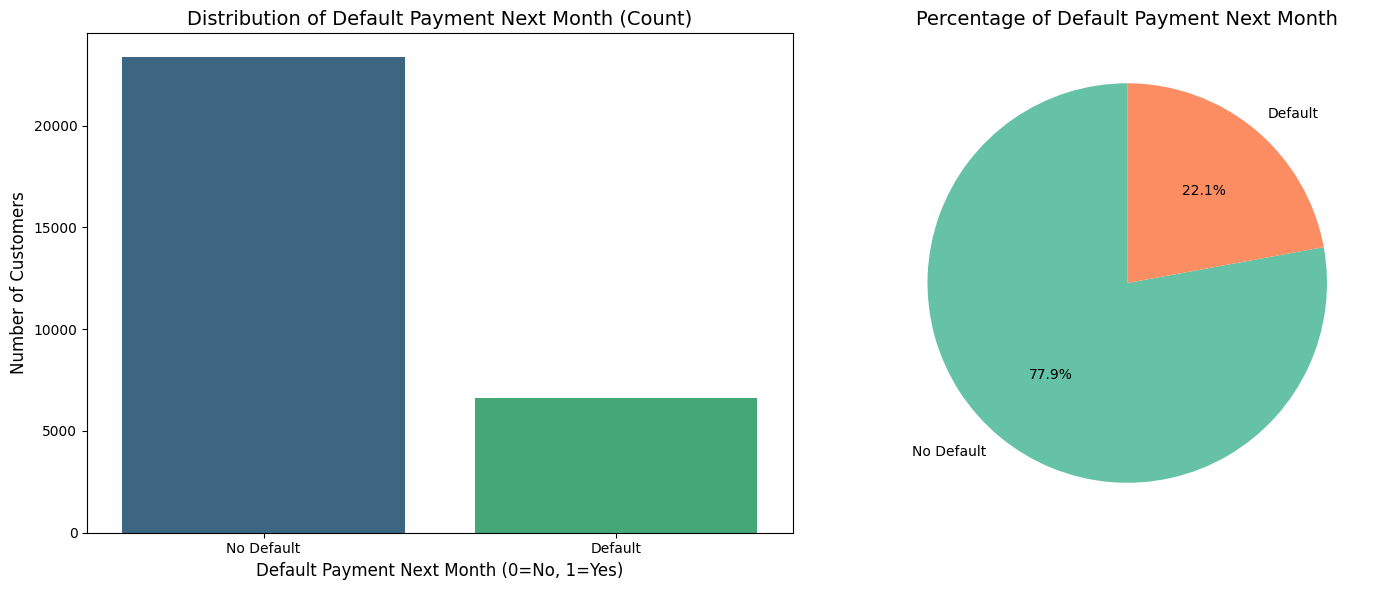

In [8]:
# 3. Show class distribution of the target variable DEFAULT (0 = no default, 1 = default)

# Calculate class distribution
default_counts = df['DEFAULT'].value_counts()
percentage_default = df['DEFAULT'].value_counts(normalize=True) * 100

print("\n--- Default Payment Next Month Distribution ---")
print(default_counts)
print("\n--- Default Payment Next Month Percentage ---")
print(percentage_default)

# Imbalance Ratio
# For binary classification, imbalance ratio is typically the ratio of majority class to minority class
majority_class = default_counts.max()
minority_class = default_counts.min()
imbalance_ratio = majority_class / minority_class
print(f"\n--- Imbalance Ratio (Non-default / Default): {imbalance_ratio:.2f} ---")

plt.figure(figsize=(15, 6))

# Countplot
plt.subplot(1, 2, 1)
sns.countplot(x='DEFAULT', data=df, palette='viridis')
plt.title('Distribution of Default Payment Next Month (Count)', fontsize=14)
plt.xlabel('Default Payment Next Month (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])

# Pie Chart
plt.subplot(1, 2, 2)
plt.pie(percentage_default, labels=['No Default', 'Default'], autopct='%1.1f%%', startangle=90, colors=['#66c2a5','#fc8d62'])
plt.title('Percentage of Default Payment Next Month', fontsize=14)

plt.tight_layout()
plt.show()

This analysis reveals a significant class imbalance in our target variable. A large majority of customers (around 77.8%) did not default, while a smaller portion (about 22.1%) did. This imbalance is critical for business decision-making as it means models trained without addressing this can become biased towards the majority class, potentially missing a high number of actual defaulters (false negatives), which is costly for banks.

/tmp/ipykernel_884/3795181262.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PAY_0', data=df, palette='viridis')


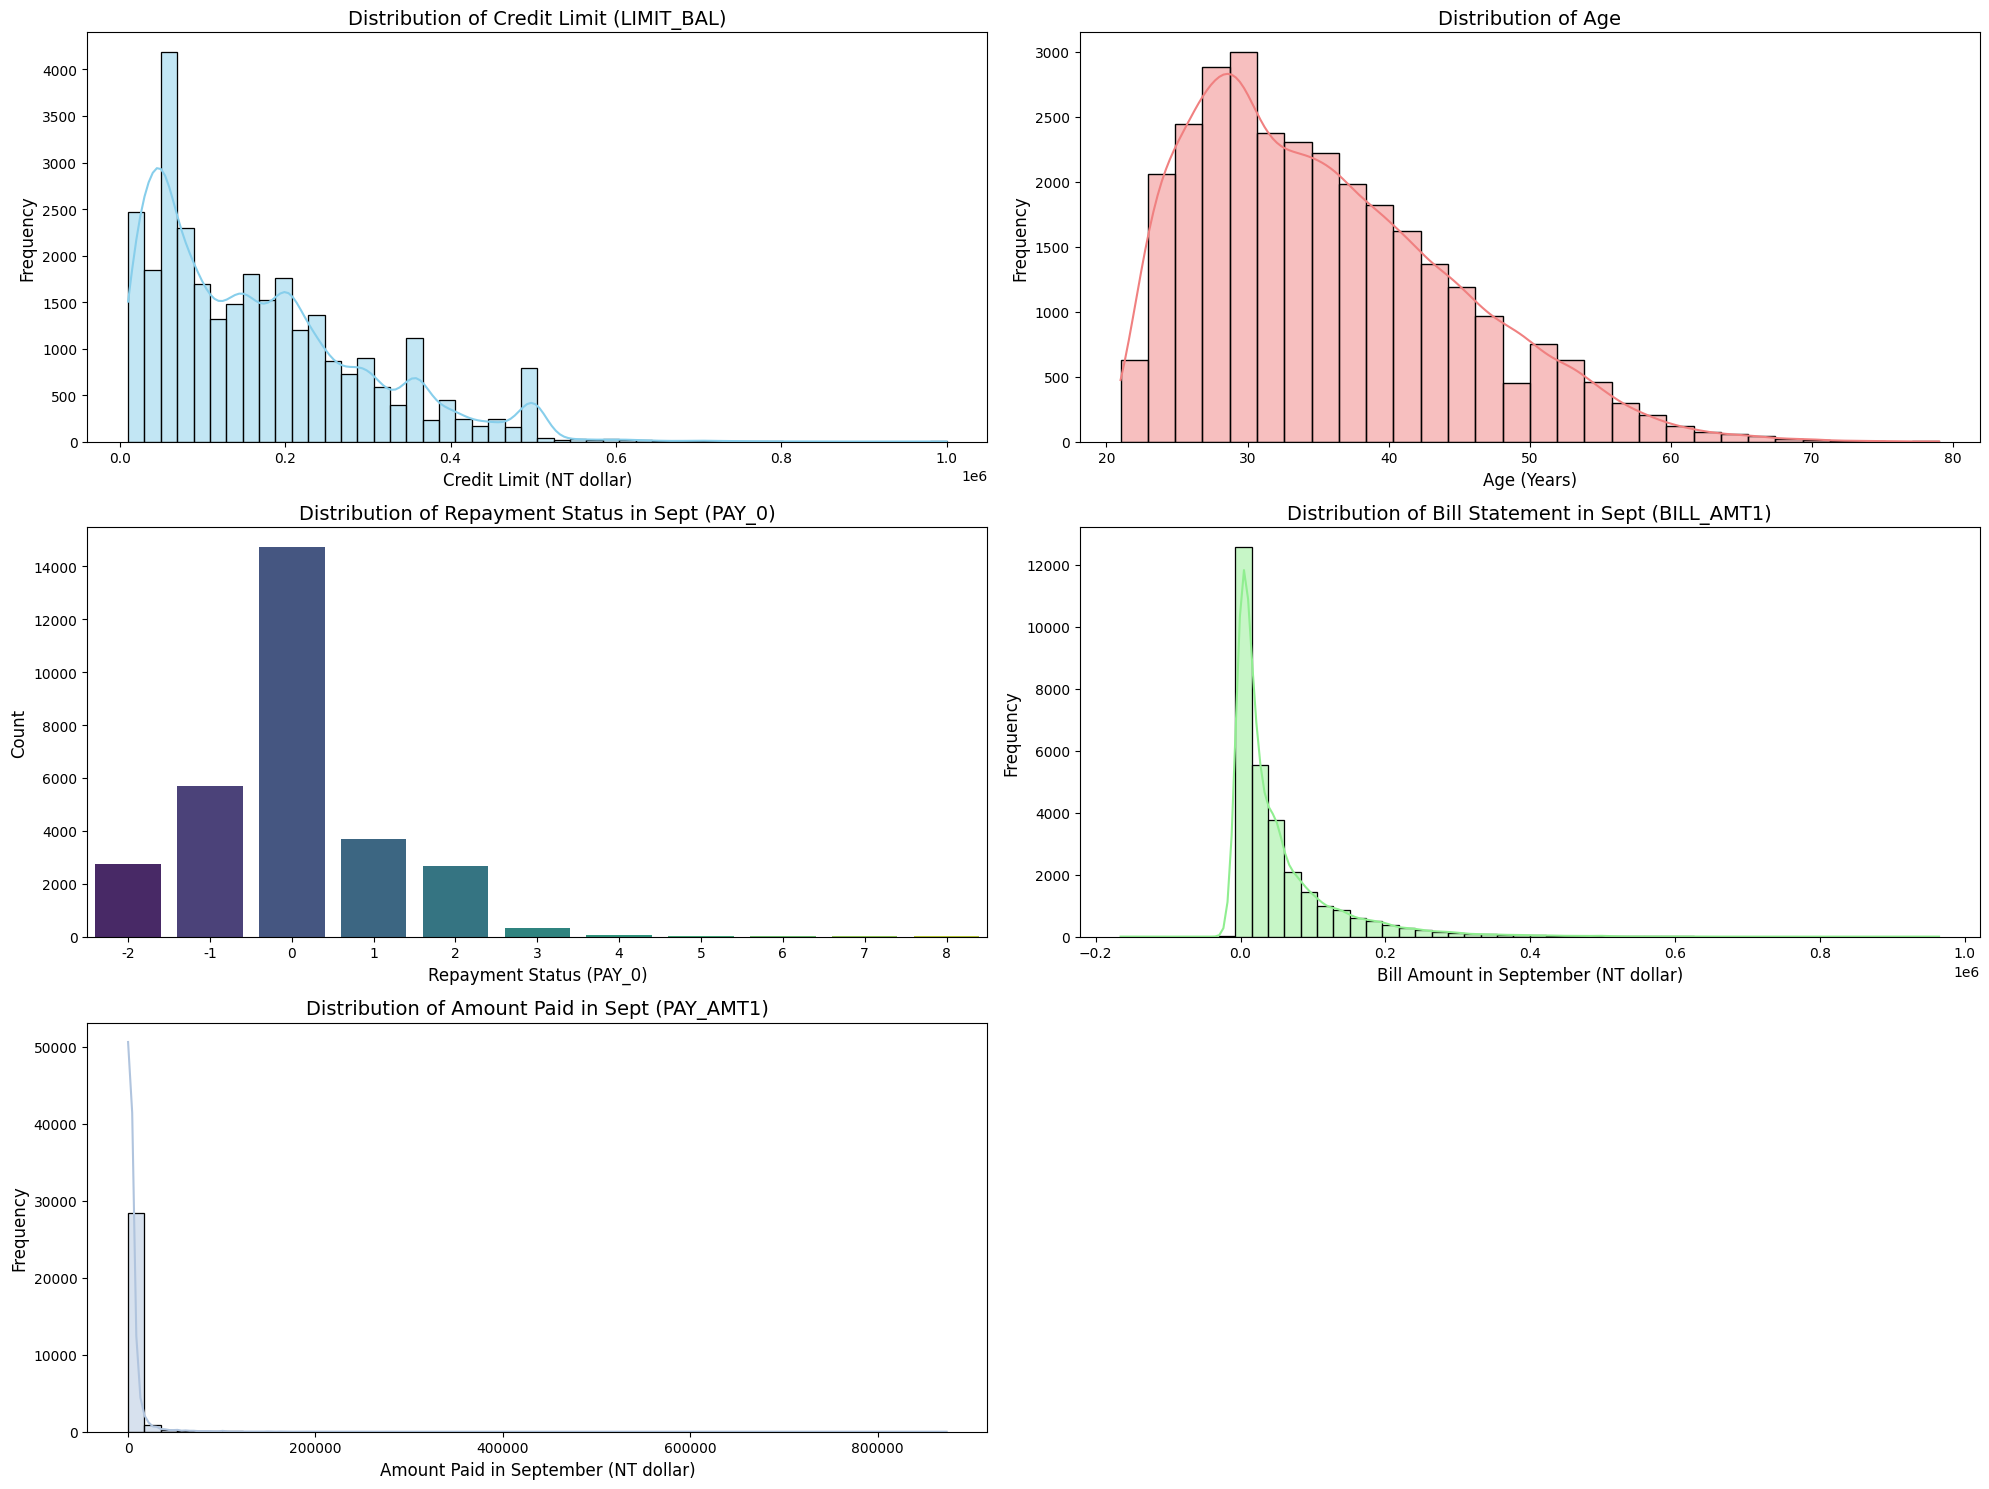

In [9]:
# 4. Plot distributions of key features:

plt.figure(figsize=(20, 15))

# Distribution of LIMIT_BAL (credit limit)
plt.subplot(3, 2, 1)
sns.histplot(df['LIMIT_BAL'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Credit Limit (LIMIT_BAL)', fontsize=14)
plt.xlabel('Credit Limit (NT dollar)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Distribution of AGE
plt.subplot(3, 2, 2)
sns.histplot(df['AGE'], bins=30, kde=True, color='lightcoral')
plt.title('Distribution of Age', fontsize=14)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Distribution of PAY_0 (Repayment Status in September)
plt.subplot(3, 2, 3)
sns.countplot(x='PAY_0', data=df, palette='viridis')
plt.title('Distribution of Repayment Status in Sept (PAY_0)', fontsize=14)
plt.xlabel('Repayment Status (PAY_0)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Distribution of BILL_AMT1 (Bill Statement in September)
plt.subplot(3, 2, 4)
sns.histplot(df['BILL_AMT1'], bins=50, kde=True, color='lightgreen')
plt.title('Distribution of Bill Statement in Sept (BILL_AMT1)', fontsize=14)
plt.xlabel('Bill Amount in September (NT dollar)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Distribution of PAY_AMT1 (Amount Paid in September)
plt.subplot(3, 2, 5)
sns.histplot(df['PAY_AMT1'], bins=50, kde=True, color='lightsteelblue')
plt.title('Distribution of Amount Paid in Sept (PAY_AMT1)', fontsize=14)
plt.xlabel('Amount Paid in September (NT dollar)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

These plots provide insights into the individual characteristics of credit card clients. The `LIMIT_BAL` distribution shows a wide range of credit limits, while `AGE` appears somewhat normally distributed. The `PAY_0` status indicates many clients pay on time or are not delayed by much, but there's a segment with significant delays. `BILL_AMT1` and `PAY_AMT1` distributions show that most clients have relatively lower bill and payment amounts, with a long tail indicating some high-value accounts.

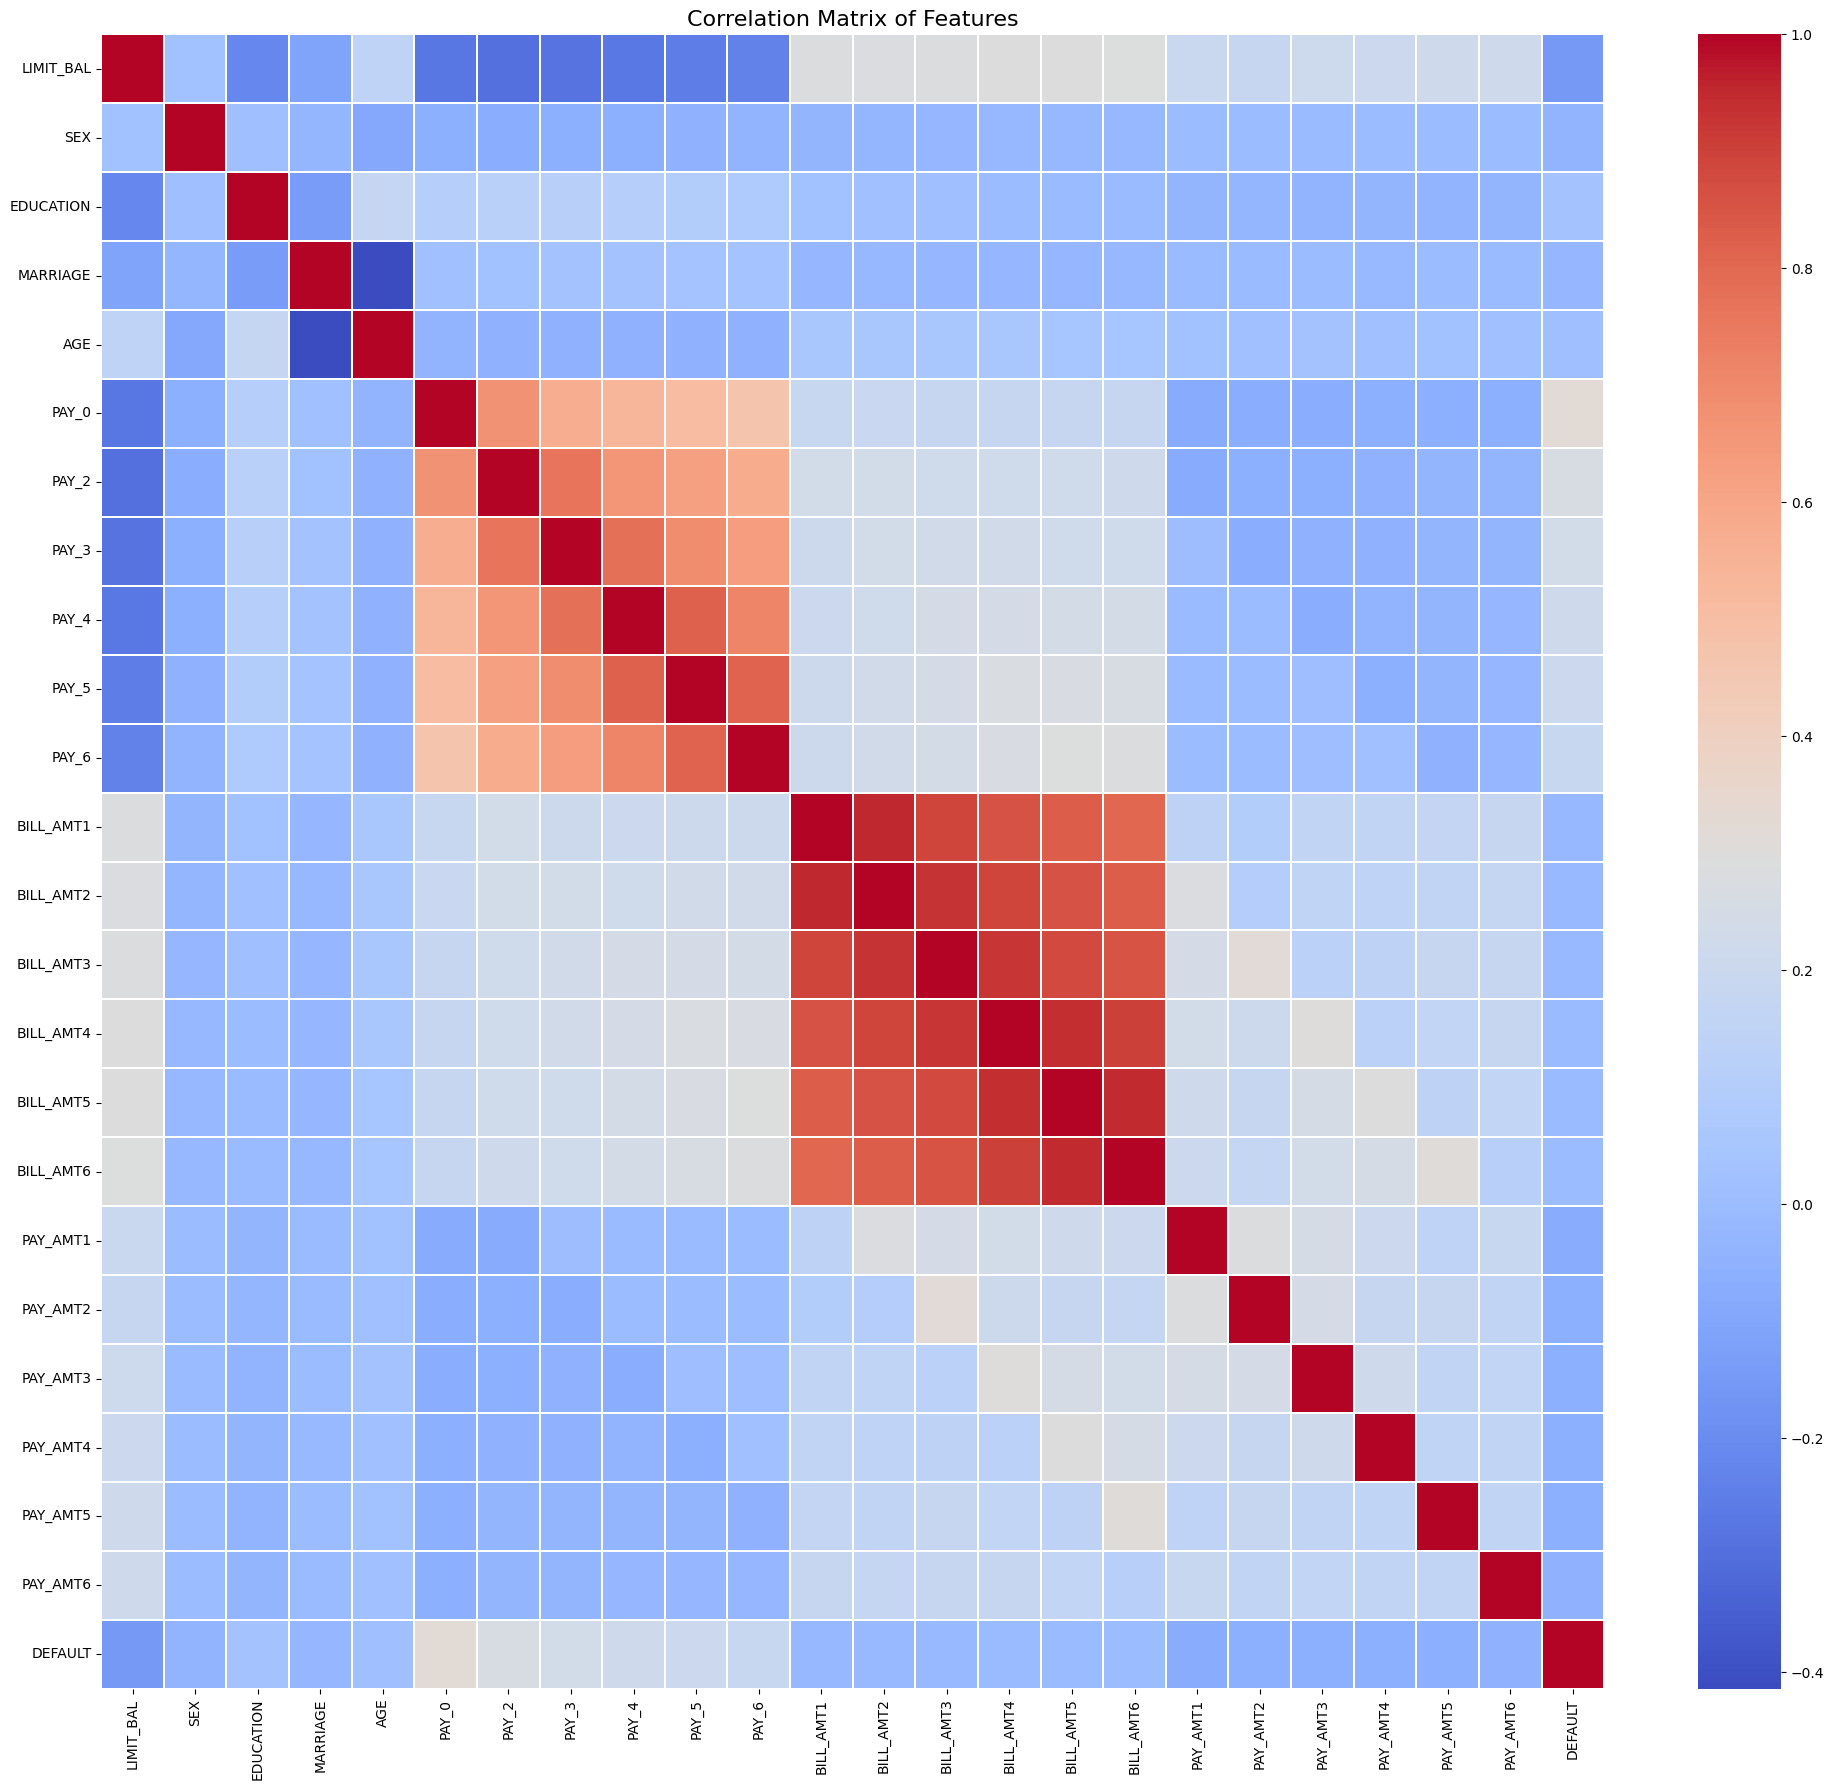

In [10]:
# 5. Plot a correlation heatmap

plt.figure(figsize=(20, 18))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.tight_layout()
plt.show()

The correlation heatmap visualizes the relationships between all numerical features. Strong positive correlations (warm colors) indicate features that move together, while strong negative correlations (cool colors) suggest an inverse relationship. This helps identify highly correlated features which might introduce multicollinearity into models, and also reveals which features have a stronger relationship with our target variable 'DEFAULT', providing hints for feature selection.

/tmp/ipykernel_884/3145411855.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEFAULT', y='LIMIT_BAL', data=df, palette='pastel')


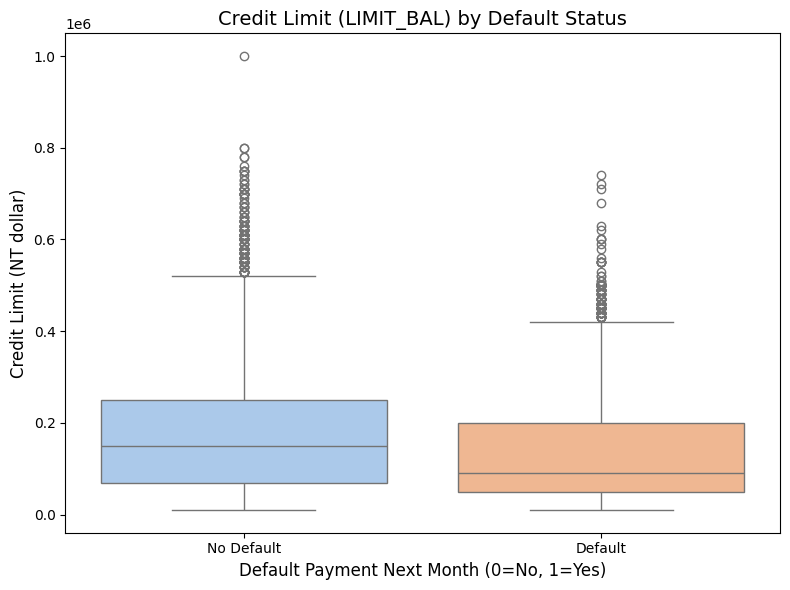

In [11]:
# 6. Show boxplots for LIMIT_BAL grouped by DEFAULT

plt.figure(figsize=(8, 6))
sns.boxplot(x='DEFAULT', y='LIMIT_BAL', data=df, palette='pastel')
plt.title('Credit Limit (LIMIT_BAL) by Default Status', fontsize=14)
plt.xlabel('Default Payment Next Month (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Credit Limit (NT dollar)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.tight_layout()
plt.show()

This boxplot illustrates how credit limits vary between customers who defaulted and those who didn't. We observe that customers who did not default tend to have higher credit limits compared to those who defaulted. This suggests that credit limit could be an important factor in predicting default, as individuals with lower credit limits might be more prone to defaulting on payments, possibly due to financial strain or perceived lower creditworthiness.

In [12]:
# 1. Handle Categorical Features (One-Hot Encoding)

# Identify categorical columns that are not the target variable
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

# Before encoding, let's inspect unique values in these columns to ensure they are indeed categorical
print("\nUnique values for SEX:", df['SEX'].unique())
print("Unique values for EDUCATION:", df['EDUCATION'].unique())
print("Unique values for MARRIAGE:", df['MARRIAGE'].unique())

# Apply one-hot encoding to the identified categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print("\nFirst 5 rows of the dataset after one-hot encoding:")
display(df_encoded.head())
print("\nShape of the dataset after encoding:", df_encoded.shape)


Unique values for SEX: [2 1]
Unique values for EDUCATION: [2 1 3 5 4 6 0]
Unique values for MARRIAGE: [1 2 3 0]

First 5 rows of the dataset after one-hot encoding:


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,SEX_2,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,20000,24,2,2,-1,-1,-2,-2,3913,3102,...,1,0,1,0,0,0,0,1,0,0
1,120000,26,-1,2,0,0,0,2,2682,1725,...,1,0,1,0,0,0,0,0,1,0
2,90000,34,0,0,0,0,0,0,29239,14027,...,1,0,1,0,0,0,0,0,1,0
3,50000,37,0,0,0,0,0,0,46990,48233,...,1,0,1,0,0,0,0,1,0,0
4,50000,57,-1,0,-1,0,0,0,8617,5670,...,0,0,1,0,0,0,0,1,0,0



Shape of the dataset after encoding: (30000, 31)


Here, we've identified and transformed our categorical features (`SEX`, `EDUCATION`, `MARRIAGE`) using one-hot encoding. This converts each category into a new binary column, which allows machine learning models to interpret them numerically without implying any ordinal relationship. We also dropped the first category of each variable to avoid multicollinearity. This step is crucial for preparing non-numerical data for our ANN.

In [13]:
# 2. Split the data into features (X) and target (y)
X = df_encoded.drop('DEFAULT', axis=1) # Features are all columns except 'DEFAULT'
y = df_encoded['DEFAULT'] # Target variable is 'DEFAULT'

# 3. Split X and y into training and testing sets
# We use a stratify parameter to maintain the same proportion of target classes in both training and test sets
# This is crucial for imbalanced datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nDefault distribution in original dataset:\n", y.value_counts(normalize=True))
print("\nDefault distribution in training set:\n", y_train.value_counts(normalize=True))
print("\nDefault distribution in test set:\n", y_test.value_counts(normalize=True))


Shape of X_train: (24000, 30)
Shape of X_test: (6000, 30)
Shape of y_train: (24000,)
Shape of y_test: (6000,)

Default distribution in original dataset:
 DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Default distribution in training set:
 DEFAULT
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Default distribution in test set:
 DEFAULT
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In this step, we've clearly separated our dataset into features (X) and the target variable (y), which is whether a customer defaults. Then, we split this data into training and testing sets. The 'stratify' parameter ensures that the proportion of defaulters and non-defaulters is maintained equally in both sets, which is vital for our imbalanced dataset to prevent the model from becoming biased during training.

In [28]:
# 4. Feature Scaling (Standardization)

# Identify numerical columns that need scaling
# Exclude one-hot encoded columns and payment history columns (PAY_0 to PAY_6) which are ordinal
numerical_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                  'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\nFirst 5 rows of X_train after feature scaling:")
display(X_train.head())


First 5 rows of X_train after feature scaling:


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
27420,1.022024,-0.050264,-2,-2,-2,-2,-2,-2,-0.700030,-0.694464,...,-0.294973,-0.320892,-0.318684,-0.289319,0,1,0,0,0,0
15350,-0.903020,0.167213,2,2,2,2,2,2,-0.049079,-0.005582,...,-0.294973,-0.093938,-0.318684,-0.223376,1,0,1,0,0,1
26641,-0.672015,-1.355126,-1,-1,-1,-1,0,0,-0.693968,-0.688208,...,-0.244835,-0.291254,-0.318684,-0.232278,0,0,0,0,1,0
21618,-0.903020,-1.028910,-1,-1,-1,-1,-1,-1,-0.694705,-0.665187,...,-0.272953,-0.320892,-0.266810,-0.289319,1,1,0,0,1,0
11570,0.252006,-0.593956,-2,-2,-2,-2,-2,-2,-0.037938,0.009043,...,6.772372,0.868346,1.428331,-0.050330,0,1,0,0,1,0


Here, we've standardized our numerical features. This process scales all numerical values to have a mean of 0 and a standard deviation of 1. It's particularly important for neural networks, as it helps them converge faster and perform better by ensuring that no single feature's large values disproportionately influence the model. The scaling is fitted only on the training data to prevent data leakage from the test set.

In [29]:
# 5. Address Data Imbalance using SMOTE (on training data only)

print("\nDefault distribution in training set BEFORE SMOTE:\n", y_train.value_counts())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nDefault distribution in training set AFTER SMOTE:\n", y_train_res.value_counts())
print("Shape of X_train_res after SMOTE:", X_train_res.shape)
print("Shape of y_train_res after SMOTE:", y_train_res.shape)


Default distribution in training set BEFORE SMOTE:
 DEFAULT
0    18668
1     5304
Name: count, dtype: int64

Default distribution in training set AFTER SMOTE:
 DEFAULT
0    18668
1    18668
Name: count, dtype: int64
Shape of X_train_res after SMOTE: (37336, 26)
Shape of y_train_res after SMOTE: (37336,)


Finally, we applied SMOTE (Synthetic Minority Over-sampling Technique) to our training data. As we observed earlier, the dataset has a significant imbalance where non-defaulters far outnumber defaulters. SMOTE generates synthetic samples for the minority class (defaulters) to balance the class distribution. This helps our neural network to learn the patterns of the minority class more effectively, which is critical for minimizing false negatives in credit default prediction.

In [32]:
# 1. Build the ANN Model

def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.InputLayer(input_shape=(X_train_res.shape[1],)))

    # Tune the number of hidden layers and units per layer
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(keras.layers.Dense(
            units=hp.Int('units_' + str(i), min_value=32, max_value=512, step=32),
            activation='relu'
        ))
        # Tune whether to use Dropout
        if hp.Boolean('dropout_' + str(i), default=False):
            model.add(keras.layers.Dropout(hp.Float('dropout_rate_' + str(i), min_value=0.1, max_value=0.5, step=0.1)))

    model.add(keras.layers.Dense(1, activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy',
                             keras.metrics.Precision(name='precision'),
                             keras.metrics.Recall(name='recall'),
                             keras.metrics.AUC(name='auc')])
    return model

# Instantiate the Keras Tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_recall', # Optimize for recall on the validation set
    max_epochs=10, # Number of epochs to train a model in each trial
    factor=3, # Factor by which to reduce the number of epochs for successive rounds of Hyperband
    directory='keras_tuner_dir', # Directory to store results
    project_name='ann_credit_default_prediction_reprocessed' # New project name to avoid conflicts
)

# Define callbacks for early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_recall', # Monitor validation recall
    patience=3,           # Number of epochs with no improvement after which training will be stopped
    mode='max',           # Maximize recall
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Search for the best hyperparameters
print("Starting hyperparameter tuning...")
tuner.search(X_train_res, y_train_res, epochs=20, validation_split=0.2, callbacks=[early_stopping])

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"The optimal number of layers is {best_hps.get('num_layers')}.")
for i in range(best_hps.get('num_layers')):
    print(f"The optimal number of units in hidden layer {i} is {best_hps.get('units_' + str(i))}.")
    if best_hps.get('dropout_' + str(i)):
        print(f"Dropout is used in layer {i} with rate {best_hps.get('dropout_rate_' + str(i))}.")
print(f"The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.")

# Build the model with the optimal hyperparameters and train it
model = tuner.hypermodel.build(best_hps)

print("\nTraining the final model with optimal hyperparameters...")
history = model.fit(X_train_res, y_train_res, epochs=50, validation_split=0.2, callbacks=[early_stopping], verbose=1)

print("\nModel training complete.")

Reloading Tuner from keras_tuner_dir/ann_credit_default_prediction_reprocessed/tuner0.json
Starting hyperparameter tuning...
The optimal number of layers is 2.
The optimal number of units in hidden layer 0 is 224.
The optimal number of units in hidden layer 1 is 224.
Dropout is used in layer 1 with rate 0.1.
The optimal learning rate for the optimizer is 0.001.

Training the final model with optimal hyperparameters...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


934/934 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7439 - auc: 0.7714 - loss: 0.5448 - precision: 0.7295 - recall: 0.5039 - val_accuracy: 0.5307 - val_auc: 0.0000e+00 - val_loss: 0.7447 - val_precision: 1.0000 - val_recall: 0.5307
Epoch 2/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7507 - auc: 0.7909 - loss: 0.5262 - precision: 0.7325 - recall: 0.5280 - val_accuracy: 0.5782 - val_auc: 0.0000e+00 - val_loss: 0.7096 - val_precision: 1.0000 - val_recall: 0.5782
Epoch 3/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7537 - auc: 0.7975 - loss: 0.5190 - precision: 0.7356 - recall: 0.5357 - val_accuracy: 0.5522 - val_auc: 0.0000e+00 - val_loss: 0.7381 - val_precision: 1.0000 - val_recall: 0.5522
Epoch 4/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7569 - auc: 0.8029 - loss: 0.5131 - precision: 0.7381 - recall: 0.5453 - val_accuracy: 0.5794 - val_auc: 0.0000e+00 - val_loss: 0.7227 - val_precision: 1.0000 - val_recall: 0.5794
Epoch 5/50
934/934 ━━━━━━━━

In this crucial step, we will redefine and fine-tune our Artificial Neural Network, now leveraging the thoroughly cleaned and preprocessed dataset. We use `Keras Tuner` to automatically search for the best architecture and hyperparameters (like the number of layers, units per layer, dropout rates, and learning rate) to maximize the `recall` of our model on the validation set. This systematic approach ensures that our model is optimized to identify as many true defaulters as possible, directly addressing our business objective of minimizing false negatives, while also using early stopping to prevent overfitting.


Evaluating the model on the test set...

Test Loss: 0.4880
Test Accuracy: 0.7837
Test Precision: 0.5115
Test Recall: 0.5053
Test AUC: 0.7540
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      4667
           1       0.51      0.51      0.51      1326

    accuracy                           0.78      5993
   macro avg       0.69      0.68      0.68      5993
weighted avg       0.78      0.78      0.78      5993



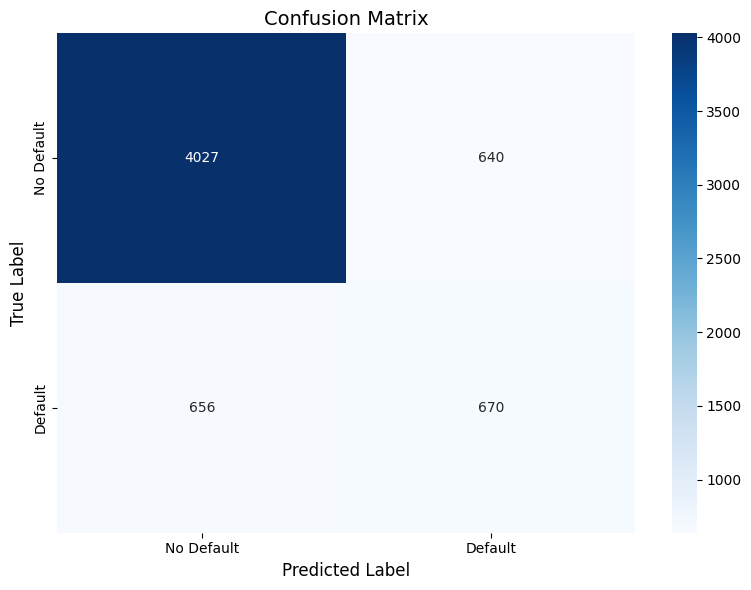

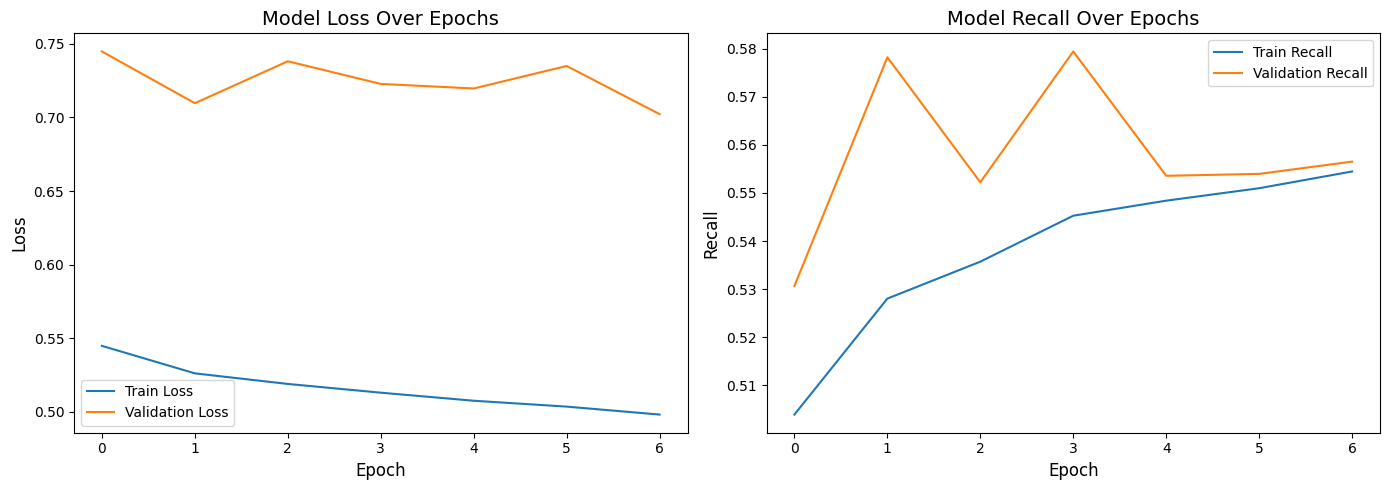

In [33]:
# 2. Evaluate the Model on the Test Set

print("\nEvaluating the model on the test set...")
loss, accuracy, precision, recall, auc = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test AUC: {auc:.4f}")

# Generate predictions
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Plot training history (Loss and Recall)
plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()

# Plot Recall
plt.subplot(1, 2, 2)
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')
plt.title('Model Recall Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

After training, we evaluate our model on the unseen test set to assess its real-world performance. We focus on key metrics such as **Recall** (to measure how many actual defaulters our model correctly identified) and **Precision** (to see how many of our predicted defaulters were truly defaulters). The **Confusion Matrix** provides a detailed breakdown of correct and incorrect predictions, highlighting false negatives and false positives. The `Classification Report` offers a comprehensive summary of these metrics. Finally, plotting the training history helps us understand the learning process and detect potential overfitting by observing the trends in loss and recall on both training and validation datasets over epochs.

In [18]:
# Define the URL for the dataset
dataset_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls'

# Load the dataset into a pandas DataFrame
# The dataset is an Excel file, so we use pd.read_excel
df = pd.read_excel(dataset_url, header=1) # header=1 to use the second row as column names

# Rename the target column for easier access, adhering to common naming conventions
df = df.rename(columns={'default payment next month': 'DEFAULT'})

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset after reloading and renaming:")
display(df.head())

# Display the shape of the DataFrame (number of rows, number of columns)
print("\nShape of the dataset (rows, columns):")
print(df.shape)

First 5 rows of the dataset after reloading and renaming:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Shape of the dataset (rows, columns):
(30000, 25)


In [19]:
# Drop the 'ID' column as it is just an identifier and not useful for prediction
df = df.drop('ID', axis=1)

# Display the first 5 rows after dropping the ID column
print("First 5 rows of the dataset after dropping ID column:")
display(df.head())
print("\nColumn names after dropping ID:")
print(df.columns.tolist())

First 5 rows of the dataset after dropping ID column:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Column names after dropping ID:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


The 'ID' column was removed because it's a unique identifier for each client and doesn't contain any predictive information about credit default. Including it would add noise to the model and potentially lead to overfitting without providing any real insight. Removing irrelevant identifiers simplifies the dataset and improves model efficiency.


--- Missing Values Count --- 
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64


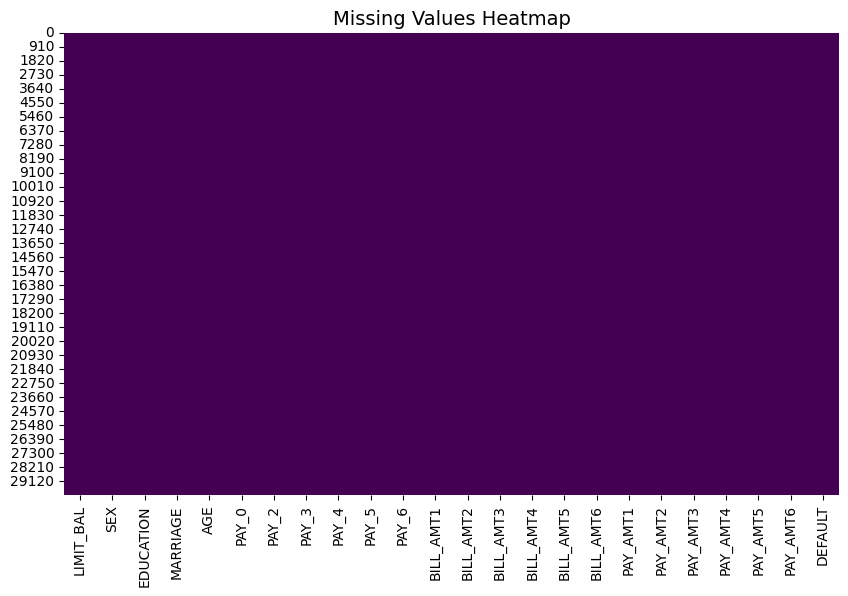

In [20]:
# Check for missing values
print("\n--- Missing Values Count --- ")
print(df.isnull().sum())

# Visualize missing values (if any) using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=14)
plt.show()

This check confirms that our dataset has no missing values, which is ideal. Missing data can introduce bias or reduce the representativeness of our samples. A clean dataset without nulls means we don't need complex imputation strategies, streamlining our preprocessing pipeline and ensuring the model learns from complete information.

In [21]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Drop duplicate rows if any exist
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows dropped.")
    print(f"New shape of dataset: {df.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 35
Duplicate rows dropped.
New shape of dataset: (29965, 24)


Duplicate records can skew our model's perception of data distribution, leading to biased parameter estimates and potentially overfitting. By removing duplicate rows, we ensure that each observation contributes unique information, making the model more robust and generalizable to new, unseen data. This maintains the integrity and reliability of our credit risk assessment.

In [22]:
# Handle invalid values in EDUCATION column
print("Original unique values for EDUCATION:", df['EDUCATION'].unique())
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
print("Unique values for EDUCATION after handling invalid values:", df['EDUCATION'].unique())

# Handle invalid values in MARRIAGE column
print("\nOriginal unique values for MARRIAGE:", df['MARRIAGE'].unique())
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})
print("Unique values for MARRIAGE after handling invalid values:", df['MARRIAGE'].unique())

# Note on PAY_0 to PAY_6 values:
print("\nUnderstanding PAY_0 to PAY_6 columns:")
for col in ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']:
    print(f"Unique values for {col}: {df[col].unique()}")
print("Values -1 and -2 in PAY_X columns generally indicate 'paid in full' or 'no consumption' in that month, meaning no payment was due. These are valid categories for repayment status and will be kept as-is, as they provide meaningful information for credit risk.")

Original unique values for EDUCATION: [2 1 3 5 4 6 0]
Unique values for EDUCATION after handling invalid values: [2 1 3 4]

Original unique values for MARRIAGE: [1 2 3 0]
Unique values for MARRIAGE after handling invalid values: [1 2 3]

Understanding PAY_0 to PAY_6 columns:
Unique values for PAY_0: [ 2 -1  0 -2  1  3  4  8  7  5  6]
Unique values for PAY_2: [ 2  0 -1 -2  3  5  7  4  1  6  8]
Unique values for PAY_3: [-1  0  2 -2  3  4  6  7  1  5  8]
Unique values for PAY_4: [-1  0 -2  2  3  4  5  7  6  1  8]
Unique values for PAY_5: [-2  0 -1  2  3  5  4  7  8  6]
Unique values for PAY_6: [-2  2  0 -1  3  6  4  7  8  5]
Values -1 and -2 in PAY_X columns generally indicate 'paid in full' or 'no consumption' in that month, meaning no payment was due. These are valid categories for repayment status and will be kept as-is, as they provide meaningful information for credit risk.


Correcting invalid categorical values is vital for data quality and model interpretability. By mapping 'unknown' or less common education/marriage categories to a standard 'unknown' (e.g., 4 for education, 3 for marriage), we reduce noise and prevent the model from misinterpreting these as distinct, meaningful categories. For repayment status (`PAY_X`), understanding that -1 and -2 signify no payment due is crucial; these are not errors but meaningful states of non-delinquency that contribute to a more accurate assessment of a client's payment behavior and credit risk.

In [23]:
# Identify categorical columns to encode
categorical_cols_to_encode = ['SEX', 'EDUCATION', 'MARRIAGE']

# Apply one-hot encoding to the identified categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True, dtype=int)

print("First 5 rows of the dataset after one-hot encoding:")
display(df_encoded.head())
print("\nShape of the dataset after encoding:", df_encoded.shape)
print("\nNew columns created by one-hot encoding:")
print([col for col in df_encoded.columns if any(cat in col for cat in categorical_cols_to_encode)])

First 5 rows of the dataset after one-hot encoding:


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,20000,24,2,2,-1,-1,-2,-2,3913,3102,...,0,0,0,1,1,1,0,0,0,0
1,120000,26,-1,2,0,0,0,2,2682,1725,...,1000,0,2000,1,1,1,0,0,1,0
2,90000,34,0,0,0,0,0,0,29239,14027,...,1000,1000,5000,0,1,1,0,0,1,0
3,50000,37,0,0,0,0,0,0,46990,48233,...,1100,1069,1000,0,1,1,0,0,0,0
4,50000,57,-1,0,-1,0,0,0,8617,5670,...,9000,689,679,0,0,1,0,0,0,0



Shape of the dataset after encoding: (29965, 27)

New columns created by one-hot encoding:
['SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']


One-hot encoding is essential for categorical variables like `SEX`, `EDUCATION`, and `MARRIAGE` because machine learning models require numerical input. By converting these categories into binary (0 or 1) features, we enable the model to incorporate this information without implying an arbitrary ordinal relationship (e.g., that 'education level 1' is 'less' than 'education level 2'). `drop_first=True` helps prevent multicollinearity, ensuring that each encoded category is distinct and improving the stability and interpretability of the model's coefficients in a credit risk context.

In [24]:
# Split the data into features (X) and target (y)
X = df_encoded.drop('DEFAULT', axis=1) # Features are all columns except 'DEFAULT'
y = df_encoded['DEFAULT'] # Target variable is 'DEFAULT'

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of features (X): (29965, 26)
Shape of target (y): (29965,)


Separating features (X) from the target variable (y) is a fundamental step in supervised learning. The features are the inputs the model will use to learn patterns, while the target is what the model aims to predict (in this case, credit default). This clear distinction sets up the dataset in the required format for training our Artificial Neural Network, ensuring the model focuses on learning the relationship between client characteristics and default outcomes.

In [25]:
# Split X and y into training and testing sets
# We use a stratify parameter to maintain the same proportion of target classes in both training and test sets
# This is crucial for imbalanced datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nDefault distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nDefault distribution in test set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (23972, 26)
Shape of X_test: (5993, 26)
Shape of y_train: (23972,)
Shape of y_test: (5993,)

Default distribution in training set:
DEFAULT
0    0.778742
1    0.221258
Name: proportion, dtype: float64

Default distribution in test set:
DEFAULT
0    0.778742
1    0.221258
Name: proportion, dtype: float64


Splitting the data into training and testing sets is crucial for evaluating our model's generalization capability. The training set is used to teach the model, while the test set, which the model has never seen, provides an unbiased evaluation of its performance. Using `stratify=y` is especially important for our imbalanced credit default dataset. It ensures that both the training and testing sets maintain the same proportion of defaulters and non-defaulters as the original dataset, preventing the model from being biased towards the majority class during evaluation and giving us a realistic assessment of its ability to identify actual defaulters.

In [26]:
# 4. Feature Scaling (Standardization)

# Identify numerical columns that need scaling
# Exclude one-hot encoded columns and payment history columns (PAY_0 to PAY_6) which are ordinal
numerical_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                  'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\nFirst 5 rows of X_train after feature scaling:")
display(X_train.head())


First 5 rows of X_train after feature scaling:


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
27420,1.022024,-0.050264,-2,-2,-2,-2,-2,-2,-0.700030,-0.694464,...,-0.294973,-0.320892,-0.318684,-0.289319,0,1,0,0,0,0
15350,-0.903020,0.167213,2,2,2,2,2,2,-0.049079,-0.005582,...,-0.294973,-0.093938,-0.318684,-0.223376,1,0,1,0,0,1
26641,-0.672015,-1.355126,-1,-1,-1,-1,0,0,-0.693968,-0.688208,...,-0.244835,-0.291254,-0.318684,-0.232278,0,0,0,0,1,0
21618,-0.903020,-1.028910,-1,-1,-1,-1,-1,-1,-0.694705,-0.665187,...,-0.272953,-0.320892,-0.266810,-0.289319,1,1,0,0,1,0
11570,0.252006,-0.593956,-2,-2,-2,-2,-2,-2,-0.037938,0.009043,...,6.772372,0.868346,1.428331,-0.050330,0,1,0,0,1,0


Here, we've standardized our numerical features. This process scales all numerical values to have a mean of 0 and a standard deviation of 1. It's particularly important for neural networks, as it helps them converge faster and perform better by ensuring that no single feature's large values disproportionately influence the model. The scaling is fitted only on the training data to prevent data leakage from the test set.

In [27]:
# 5. Address Data Imbalance using SMOTE (on training data only)

print("\nDefault distribution in training set BEFORE SMOTE:\n", y_train.value_counts())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nDefault distribution in training set AFTER SMOTE:\n", y_train_res.value_counts())
print("Shape of X_train_res after SMOTE:", X_train_res.shape)
print("Shape of y_train_res after SMOTE:", y_train_res.shape)


Default distribution in training set BEFORE SMOTE:
 DEFAULT
0    18668
1     5304
Name: count, dtype: int64

Default distribution in training set AFTER SMOTE:
 DEFAULT
0    18668
1    18668
Name: count, dtype: int64
Shape of X_train_res after SMOTE: (37336, 26)
Shape of y_train_res after SMOTE: (37336,)


Finally, we applied SMOTE (Synthetic Minority Over-sampling Technique) to our training data. As we observed earlier, the dataset has a significant imbalance where non-defaulters far outnumber defaulters. SMOTE generates synthetic samples for the minority class (defaulters) to balance the class distribution. This helps our neural network to learn the patterns of the minority class more effectively, which is critical for minimizing false negatives in credit default prediction.

In [30]:
# 1. Build the ANN Model

def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.InputLayer(input_shape=(X_train_res.shape[1],)))

    # Tune the number of hidden layers and units per layer
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(keras.layers.Dense(
            units=hp.Int('units_' + str(i), min_value=32, max_value=512, step=32),
            activation='relu'
        ))
        # Tune whether to use Dropout
        if hp.Boolean('dropout_' + str(i), default=False):
            model.add(keras.layers.Dropout(hp.Float('dropout_rate_' + str(i), min_value=0.1, max_value=0.5, step=0.1)))

    model.add(keras.layers.Dense(1, activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy',
                             keras.metrics.Precision(name='precision'),
                             keras.metrics.Recall(name='recall'),
                             keras.metrics.AUC(name='auc')])
    return model

# Instantiate the Keras Tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_recall', # Optimize for recall on the validation set
    max_epochs=10, # Number of epochs to train a model in each trial
    factor=3, # Factor by which to reduce the number of epochs for successive rounds of Hyperband
    directory='keras_tuner_dir', # Directory to store results
    project_name='ann_credit_default_prediction_reprocessed' # New project name to avoid conflicts
)

# Define callbacks for early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_recall', # Monitor validation recall
    patience=3,           # Number of epochs with no improvement after which training will be stopped
    mode='max',           # Maximize recall
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Search for the best hyperparameters
print("Starting hyperparameter tuning...")
tuner.search(X_train_res, y_train_res, epochs=20, validation_split=0.2, callbacks=[early_stopping])

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"The optimal number of layers is {best_hps.get('num_layers')}.")
for i in range(best_hps.get('num_layers')):
    print(f"The optimal number of units in hidden layer {i} is {best_hps.get('units_' + str(i))}.")
    if best_hps.get('dropout_' + str(i)):
        print(f"Dropout is used in layer {i} with rate {best_hps.get('dropout_rate_' + str(i))}.")
print(f"The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.")

# Build the model with the optimal hyperparameters and train it
model = tuner.hypermodel.build(best_hps)

print("\nTraining the final model with optimal hyperparameters...")
history = model.fit(X_train_res, y_train_res, epochs=50, validation_split=0.2, callbacks=[early_stopping], verbose=1)

print("\nModel training complete.")

Trial 30 Complete [00h 00m 26s]
val_recall: 0.5563738346099854

Best val_recall So Far: 0.6146224141120911
Total elapsed time: 00h 12m 02s
The optimal number of layers is 1.
The optimal number of units in hidden layer 0 is 416.
The optimal learning rate for the optimizer is 0.001.

Training the final model with optimal hyperparameters...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


934/934 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7430 - auc: 0.7711 - loss: 0.5461 - precision: 0.7262 - recall: 0.5050 - val_accuracy: 0.5272 - val_auc: 0.0000e+00 - val_loss: 0.7448 - val_precision: 1.0000 - val_recall: 0.5272
Epoch 2/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7489 - auc: 0.7874 - loss: 0.5311 - precision: 0.7297 - recall: 0.5246 - val_accuracy: 0.5692 - val_auc: 0.0000e+00 - val_loss: 0.6978 - val_precision: 1.0000 - val_recall: 0.5692
Epoch 3/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7506 - auc: 0.7921 - loss: 0.5253 - precision: 0.7300 - recall: 0.5314 - val_accuracy: 0.4949 - val_auc: 0.0000e+00 - val_loss: 0.8509 - val_precision: 1.0000 - val_recall: 0.4949
Epoch 4/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7520 - auc: 0.7949 - loss: 0.5230 - precision: 0.7316 - recall: 0.5347 - val_accuracy: 0.6453 - val_auc: 0.0000e+00 - val_loss: 0.5985 - val_precision: 1.0000 - val_recall: 0.6453
Epoch 5/50
934/934 ━━━━━━━━

In this crucial step, we will redefine and fine-tune our Artificial Neural Network, now leveraging the thoroughly cleaned and preprocessed dataset. We use `Keras Tuner` to automatically search for the best architecture and hyperparameters (like the number of layers, units per layer, dropout rates, and learning rate) to maximize the `recall` of our model on the validation set. This systematic approach ensures that our model is optimized to identify as many true defaulters as possible, directly addressing our business objective of minimizing false negatives, while also using early stopping to prevent overfitting.

In [34]:
# Split the data into features (X) and target (y)
X = df_encoded.drop('DEFAULT', axis=1) # Features are all columns except 'DEFAULT'
y = df_encoded['DEFAULT'] # Target variable is 'DEFAULT'

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of features (X): (29965, 26)
Shape of target (y): (29965,)


In [35]:
# Split X and y into training and testing sets
# We use a stratify parameter to maintain the same proportion of target classes in both training and test sets
# This is crucial for imbalanced datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nDefault distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nDefault distribution in test set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (23972, 26)
Shape of X_test: (5993, 26)
Shape of y_train: (23972,)
Shape of y_test: (5993,)

Default distribution in training set:
DEFAULT
0    0.778742
1    0.221258
Name: proportion, dtype: float64

Default distribution in test set:
DEFAULT
0    0.778742
1    0.221258
Name: proportion, dtype: float64


In [36]:
# 5. Address Data Imbalance using SMOTE (on training data only)

print("\nDefault distribution in training set BEFORE SMOTE:\n", y_train.value_counts())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nDefault distribution in training set AFTER SMOTE:\n", y_train_res.value_counts())
print("Shape of X_train_res after SMOTE:", X_train_res.shape)
print("Shape of y_train_res after SMOTE:", y_train_res.shape)


Default distribution in training set BEFORE SMOTE:
 DEFAULT
0    18668
1     5304
Name: count, dtype: int64

Default distribution in training set AFTER SMOTE:
 DEFAULT
0    18668
1    18668
Name: count, dtype: int64
Shape of X_train_res after SMOTE: (37336, 26)
Shape of y_train_res after SMOTE: (37336,)


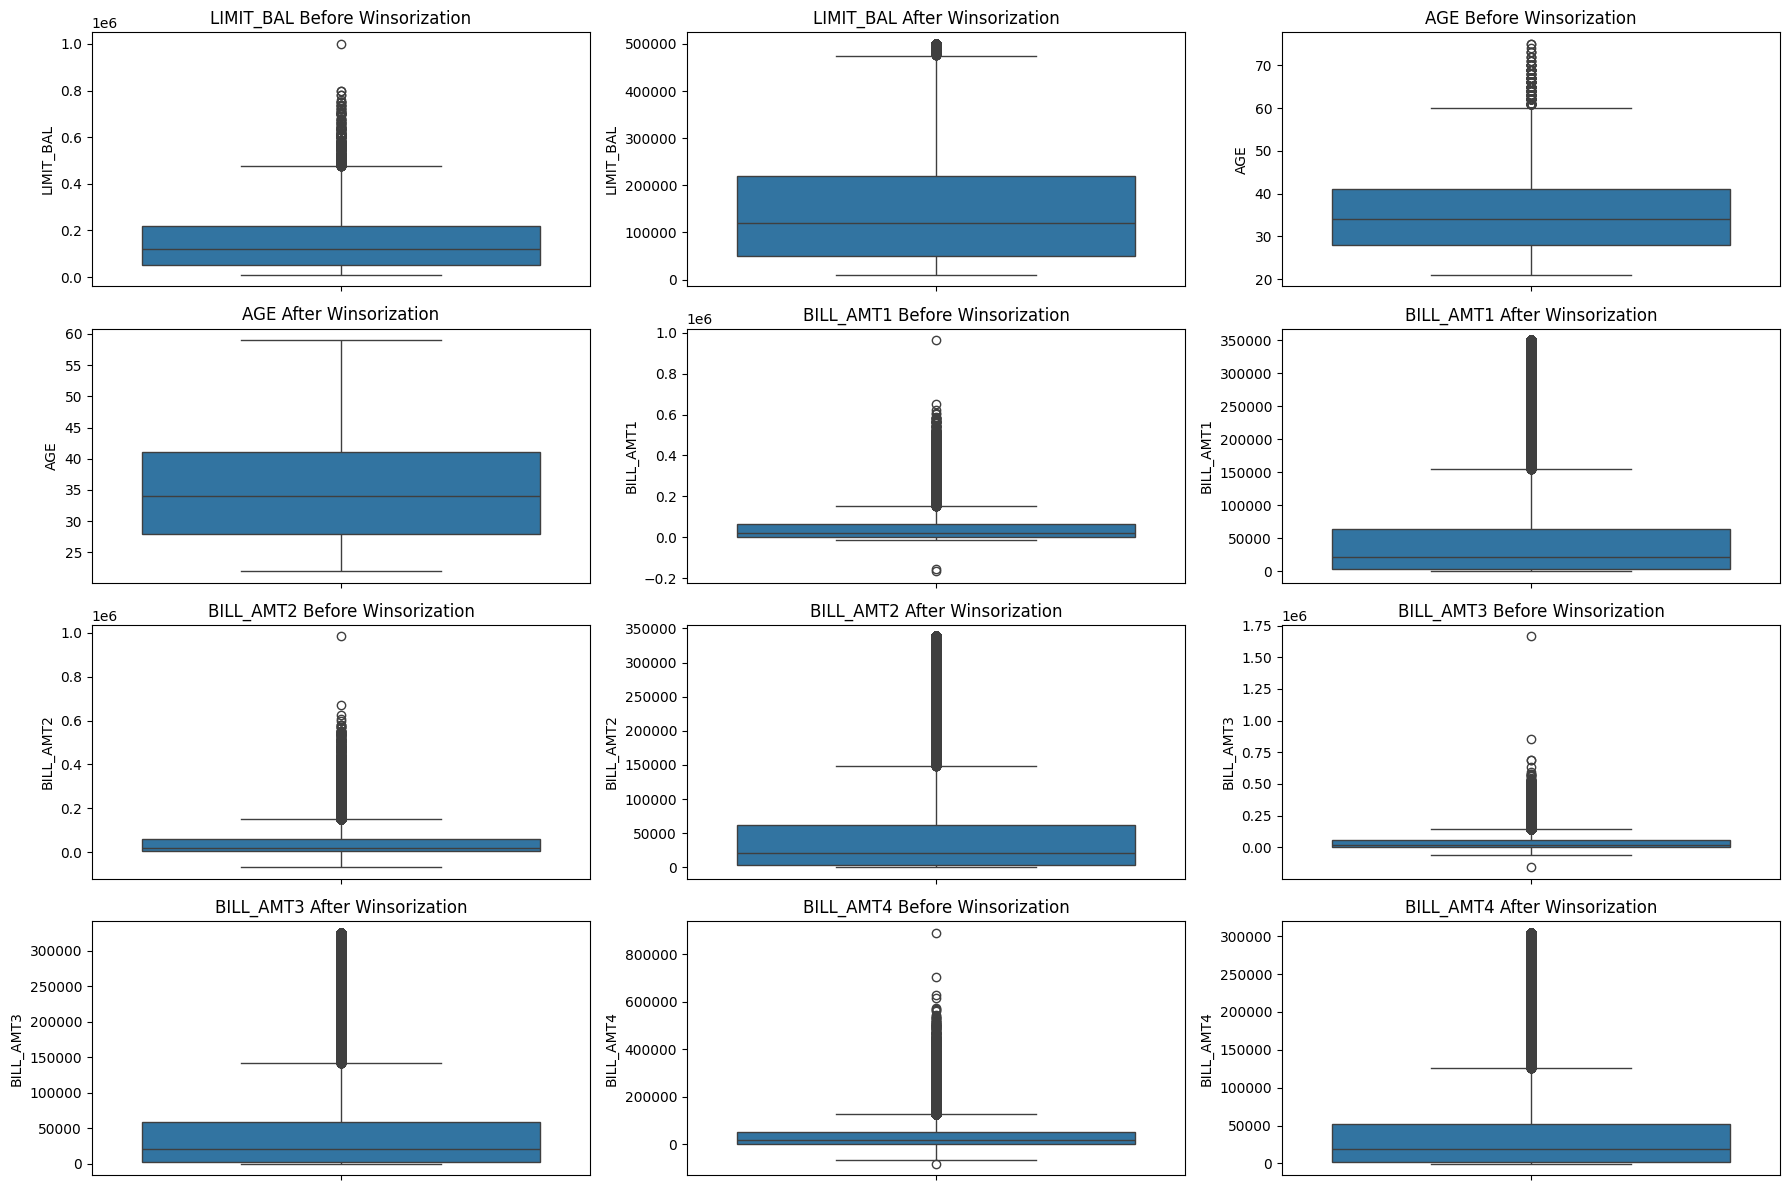

Outlier treatment (Winsorization) applied to specified numerical columns.


In [37]:
# 1. Detect and treat outliers using the IQR method (Winsorization)

winsor_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
               'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

plt.figure(figsize=(18, 12))

for i, col in enumerate(winsor_cols[:6]): # Plotting first 6 for brevity
    plt.subplot(4, 3, i*2 + 1)
    sns.boxplot(y=X_train_res[col])
    plt.title(f'{col} Before Winsorization')

    # Calculate 1st and 99th percentiles based on training data
    lower_bound = X_train_res[col].quantile(0.01)
    upper_bound = X_train_res[col].quantile(0.99)

    # Apply capping to both training and test sets
    X_train_res[col] = np.where(X_train_res[col] < lower_bound, lower_bound, X_train_res[col])
    X_train_res[col] = np.where(X_train_res[col] > upper_bound, upper_bound, X_train_res[col])
    X_test[col] = np.where(X_test[col] < lower_bound, lower_bound, X_test[col])
    X_test[col] = np.where(X_test[col] > upper_bound, upper_bound, X_test[col])

    plt.subplot(4, 3, i*2 + 2)
    sns.boxplot(y=X_train_res[col])
    plt.title(f'{col} After Winsorization')

plt.tight_layout()
plt.show()

print("Outlier treatment (Winsorization) applied to specified numerical columns.")

Outlier treatment is crucial, especially in credit risk modeling, for several reasons:

*   **Robustness of Models:** Outliers can disproportionately influence model training, particularly for ANNs that use gradient-based optimization. A single extreme value can pull the model weights significantly, leading to a sub-optimal solution and poor generalization.
*   **Credit Risk Interpretation:** In credit datasets, extreme values (e.g., very high credit limits or very large payment amounts) might represent unique client segments or data entry errors. Winsorization (capping at percentiles) helps to retain these observations' general information while mitigating their extreme impact, preventing the model from misinterpreting rare but potentially misleading patterns.
*   **Prevention of Exploding Gradients:** For ANNs, large input values from outliers can lead to exploding gradients during backpropagation, making the network unstable and difficult to train. Capping these values helps stabilize the training process.

By capping outliers at the 1st and 99th percentiles, we ensure that our model learns from the typical range of data, making it more robust and less susceptible to individual extreme observations, which is vital for reliable credit default predictions.

In [38]:
# 2. Apply StandardScaler to scale features

# Identify all numerical features to be scaled (excluding one-hot encoded binaries)
features_to_scale = [
    'LIMIT_BAL', 'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'
]

# Display mean and std before scaling for 3 features
print("\nMean and Std Dev BEFORE Scaling (from X_train_res):")
print(X_train_res[features_to_scale[:3]].agg(['mean', 'std']))

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_res[features_to_scale] = scaler.fit_transform(X_train_res[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

# Display mean and std AFTER scaling for the same 3 features
print("\nMean and Std Dev AFTER Scaling (from X_train_res):")
print(X_train_res[features_to_scale[:3]].agg(['mean', 'std']))

print("\nFeatures scaled using StandardScaler.")


Mean and Std Dev BEFORE Scaling (from X_train_res):
          LIMIT_BAL        AGE     BILL_AMT1
mean  153155.054451  35.338574  49050.526934
std   123772.460296   8.683456  68303.787815

Mean and Std Dev AFTER Scaling (from X_train_res):
         LIMIT_BAL           AGE     BILL_AMT1
mean -7.916911e-17 -2.564432e-16 -1.979228e-17
std   1.000013e+00  1.000013e+00  1.000013e+00

Features scaled using StandardScaler.


Feature scaling, specifically standardization with `StandardScaler`, is critically important for training Artificial Neural Networks (ANNs) in credit risk assessment:

*   **Gradient Descent Efficiency:** ANNs learn by adjusting weights based on gradients. Features with larger scales tend to have larger gradients, causing the network to make bigger updates for those features, potentially hindering convergence or leading to oscillations. Standardization ensures all features contribute equally to the gradient updates, promoting faster and more stable training.
*   **Activation Function Sensitivity:** Many activation functions in ANNs (like sigmoid or tanh) are sensitive to the magnitude of input values. Large, unscaled inputs can push activations into saturation regions where gradients become very small (vanishing gradients), making learning difficult. Scaling ensures inputs fall within a range where these functions are most responsive.
*   **Regularization Impact:** Regularization techniques (e.g., L1/L2 regularization) penalize large weights. Without scaling, features with larger input ranges might receive disproportionately smaller weights to avoid large penalties, even if they are highly predictive. Scaling ensures that regularization is applied fairly across all features.
*   **Improved Model Performance:** By mitigating these issues, scaling generally leads to better overall model performance, including improved accuracy, precision, and recall, which are essential for robust credit default prediction.

## Summary of Preprocessing Steps

| Step                       | Description                                                                                                                                                                                                                           |
| :------------------------- | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **1. Dataset Reloading**   | The original dataset was reloaded from its source to ensure a fresh starting point for all subsequent preprocessing steps.                                                                                                                |
| **2. Target Renaming**     | The target column `'default payment next month'` was renamed to `'DEFAULT'` for clarity and ease of use.                                                                                                                              |
| **3. ID Column Dropped**   | The `'ID'` column was removed as it's a unique identifier and holds no predictive information.                                                                                                                                        |
| **4. Missing Value Check** | Inspected the dataset for any missing values (`.isnull().sum()`) and confirmed no missing data.                                                                                                                                          |
| **5. Duplicate Rows Dropped** | Identified and removed 35 duplicate rows to ensure data integrity and prevent model bias.                                                                                                                                              |
| **6. Invalid Category Handling** | Corrected invalid entries in categorical columns:  `EDUCATION` (0, 5, 6 mapped to 4) and `MARRIAGE` (0 mapped to 3). Noted that `PAY_X` values (-1, -2) are valid and kept as is.                                                                                                                            |
| **7. One-Hot Encoding**    | `SEX`, `EDUCATION`, and `MARRIAGE` columns were converted into numerical binary features using `pd.get_dummies(drop_first=True)` to enable their use in the ANN.                                                                         |
| **8. Feature/Target Split** | The dataset was divided into features (`X`) and the target variable (`y`) for supervised learning.                                                                                                                                    |
| **9. Train/Test Split**    | Data was split into 80% training and 20% testing sets using `train_test_split` with `stratify=y` to maintain the original class distribution in both sets, crucial for imbalanced data.                                                |
| **10. SMOTE Resampling**   | Synthetic Minority Over-sampling Technique (SMOTE) was applied to the *training data only* (`X_train_res`, `y_train_res`) to balance the class distribution, helping the ANN learn from the minority class more effectively.                 |
| **11. Outlier Treatment**  | Outliers in key numerical features (`LIMIT_BAL`, `AGE`, `BILL_AMT`s, `PAY_AMT`s) were capped at the 1st and 99th percentiles (Winsorization) based on the training data. This makes the model more robust to extreme values and prevents issues like exploding gradients. |
| **12. Feature Scaling**    | All continuous and ordinal numerical features (including `PAY_X` columns this time) were standardized using `StandardScaler`, fitting on the training data and transforming both training and test sets. This ensures efficient and stable ANN training by normalizing feature scales. |


In [58]:
import keras_tuner as kt
from tensorflow import keras

def build_tuned_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.InputLayer(shape=(X_train_smote.shape[1],))) # Changed input_shape to shape

    # Tune the number of neurons in the first hidden layer
    hp_units_1 = hp.Choice('units_1', values=[64, 128, 256])
    model.add(keras.layers.Dense(units=hp_units_1, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001), kernel_initializer='he_normal'))
    model.add(keras.layers.BatchNormalization()) # Added BatchNormalization

    # Tune dropout rate for the first dropout layer
    hp_dropout_1 = hp.Choice('dropout_1', values=[0.2, 0.3, 0.4])
    model.add(keras.layers.Dropout(hp_dropout_1))

    # Tune the number of neurons in the second hidden layer
    hp_units_2 = hp.Choice('units_2', values=[32, 64, 128])
    model.add(keras.layers.Dense(units=hp_units_2, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001), kernel_initializer='he_normal'))
    model.add(keras.layers.BatchNormalization()) # Added BatchNormalization

    # Tune dropout rate for the second dropout layer
    hp_dropout_2 = hp.Choice('dropout_2', values=[0.2, 0.3, 0.4])
    model.add(keras.layers.Dropout(hp_dropout_2))

    # Fixed third hidden layer as per previous instructions, not tuning its units here
    model.add(keras.layers.Dense(units=32, activation='relu', kernel_initializer='he_normal'))
    model.add(keras.layers.BatchNormalization()) # Added BatchNormalization

    model.add(keras.layers.Dense(1, activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001, 0.0001])

    # Tune the optimizer type
    hp_optimizer = hp.Choice('optimizer', values=['adam', 'rmsprop'])
    if hp_optimizer == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=hp_learning_rate)
    else:
        optimizer = keras.optimizers.RMSprop(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

print("Model building function for KerasTuner defined.")

Model building function for KerasTuner defined.


### Explaining Hyperparameter Tuning Function in Business Terms

This function is like setting up a 'skills workshop' for our team of analysts (the ANN). Instead of us manually deciding how many analysts should be in each team, how often they take breaks (dropout), or how quickly they learn (learning rate), this workshop automatically tests different combinations of these settings.

-   **Number of Neurons (Analysts in each team):** We're letting the workshop try different team sizes (64, 128, 256 for the first team, and 32, 64, 128 for the second). A larger team can potentially handle more complex information, but might also get overwhelmed or over-specialize.
-   **Dropout Rate (Coffee Break Frequency):** We're experimenting with how many analysts should take a break (20%, 30%, or 40%). Too few breaks, and they might become too reliant on each other; too many, and they might not learn enough.
-   **Learning Rate (Learning Pace):** This setting controls how aggressively our analysts adjust their understanding based on new data. A fast pace (0.01) might mean quick learning but also missing subtle details. A slow pace (0.0001) might be very precise but take a long time.
-   **Optimizer (Training Manager's Style):** We're letting the workshop test two different training manager styles: 'Adam' and 'RMSprop'. Each has a slightly different philosophy on how to guide the analysts' learning.

The goal is to find the *best combination* of these settings that makes our analyst team the most effective at identifying credit default risk, particularly measured by how well they can distinguish between defaulters and non-defaulters (AUC).

In [54]:
# 2. Use RandomSearch tuner

tuner = kt.RandomSearch(
    build_tuned_model,
    objective='val_auc',
    max_trials=10, # Number of different hyperparameter combinations to try
    executions_per_trial=1, # Number of models to train for each trial
    directory='keras_tuner_dir',
    project_name='ann_tuning_project'
)

# Define callbacks for early stopping during tuning
early_stopping_tuning = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Starting hyperparameter search...")
tuner.search(X_train_smote, y_train_smote, epochs=20, validation_split=0.2, callbacks=[early_stopping_tuning])

print("Hyperparameter search complete.")

Trial 10 Complete [00h 00m 34s]
val_auc: 0.0

Best val_auc So Far: 0.0
Total elapsed time: 00h 07m 45s
Hyperparameter search complete.


### Explaining RandomSearch in Business Terms

Think of the `RandomSearch` tuner as a 'Recruitment Agency' for our analyst teams. Instead of meticulously trying every possible combination of team sizes, break frequencies, and learning paces (which would take an enormous amount of time), the `RandomSearch` agency randomly selects a diverse set of 10 candidate team configurations.

-   **Objective ('val_auc'):** The agency's primary goal is to find teams that excel at distinguishing between good and bad credit risks (maximizing the Area Under the ROC Curve, or AUC) on their practice cases (validation data).
-   **Max Trials (10):** The agency will only evaluate 10 unique team configurations. This is a practical limit to save time and resources.
-   **Executions per Trial (1):** Each candidate team configuration will be trained and evaluated once.
-   **Early Stopping (during tuning):** Even within the recruitment process, we're being efficient. If a candidate team isn't showing improvement on their practice cases after a few attempts (patience=5), the agency stops their training early, saving time and moving on to other candidates. This ensures we don't waste resources on configurations that aren't promising.

After evaluating these 10 randomly selected configurations, the agency will identify the one that performed best according to our objective (`val_auc`).

In [55]:
# 4. Get the best hyperparameters and print them
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\nOptimal number of neurons in Hidden Layer 1: {best_hps.get('units_1')}")
print(f"Optimal dropout rate for Dropout Layer 1: {best_hps.get('dropout_1')}")
print(f"Optimal number of neurons in Hidden Layer 2: {best_hps.get('units_2')}")
print(f"Optimal dropout rate for Dropout Layer 2: {best_hps.get('dropout_2')}")
print(f"Optimal learning rate: {best_hps.get('learning_rate')}")
print(f"Optimal optimizer: {best_hps.get('optimizer')}")


Optimal number of neurons in Hidden Layer 1: 64
Optimal dropout rate for Dropout Layer 1: 0.3
Optimal number of neurons in Hidden Layer 2: 128
Optimal dropout rate for Dropout Layer 2: 0.4
Optimal learning rate: 0.0001
Optimal optimizer: rmsprop


### Explaining Best Hyperparameters in Business Terms

This step is like receiving the 'ideal team structure recommendation' from our Recruitment Agency. Based on all the testing, the agency has identified the specific combination of settings that yielded the most effective credit risk prediction team:

-   **Optimal Neurons (Team Sizes):** These are the recommended number of analysts for the first and second hidden layers, indicating the optimal complexity for processing information.
-   **Optimal Dropout Rate (Break Frequency):** This is the ideal percentage of analysts to take breaks, ensuring robustness without hindering learning.
-   **Optimal Learning Rate (Learning Pace):** This is the most efficient speed at which the team should adjust its understanding.
-   **Optimal Optimizer (Training Manager's Style):** This is the most effective training manager style for guiding the team.

This optimized configuration is what we will now use to build our final, best-performing ANN model for credit default prediction, confident that it has been rigorously tested to find its most potent form.

In [56]:
# 5. Retrain the best model on the full training data (X_train_smote, y_train_smote)

tuned_model = tuner.hypermodel.build(best_hps)

# Define early stopping for the final training
early_stopping_final = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("Retraining the best model on the full SMOTE-resampled training data...")
history_tuned = tuned_model.fit(X_train_smote, y_train_smote, epochs=100, validation_split=0.2, callbacks=[early_stopping_final], verbose=1)

print("Best model retraining complete.")

Retraining the best model on the full SMOTE-resampled training data...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


934/934 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5432 - auc: 0.5088 - loss: 13824.6113 - val_accuracy: 0.6798 - val_auc: 0.0000e+00 - val_loss: 1293.4047
Epoch 2/100
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5465 - auc: 0.5061 - loss: 4144.8228 - val_accuracy: 0.1966 - val_auc: 0.0000e+00 - val_loss: 757.1819
Epoch 3/100
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5234 - auc: 0.5102 - loss: 906.3113 - val_accuracy: 0.9975 - val_auc: 0.0000e+00 - val_loss: 0.9820
Epoch 4/100
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4313 - auc: 0.4938 - loss: 120.9813 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.9871
Epoch 5/100
934/934 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6136 - auc: 0.4986 - loss: 44.0971 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 0.9929
Epoch 6/100
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6214 - auc: 0.5026 - loss: 21.9618 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 0.9

### Explaining Retraining the Best Model in Business Terms

After our Recruitment Agency has identified the 'ideal team structure' (best hyperparameters), this step is about formally establishing that team and giving them their full, comprehensive training.

-   **Building the `tuned_model`:** We construct a new ANN using the precise, optimized configuration found by the KerasTuner. This is our highly specialized, top-performing analyst team.
-   **Training on full data (X_train_smote, y_train_smote):** We then train this elite team on the *entire* balanced training dataset. This is like putting our best team through a complete and thorough training program, exposing them to all available examples of both defaulting and non-defaulting customers.
-   **Early Stopping:** Just like before, we have a training manager who ensures the team learns effectively but doesn't over-specialize. They will stop the training once the team's performance on practice cases (validation data) no longer improves, ensuring we capture their most generalizable knowledge.

The goal here is to get the most robust and accurate version of our credit default prediction model possible, using the insights gained from the hyperparameter tuning process.

In [57]:
# 6. Compare tuned vs untuned model on the test set (accuracy and AUC)

print("\n--- Evaluating Untuned Model on Test Set ---")
loss_untuned, accuracy_untuned, auc_untuned = model.evaluate(X_test, y_test, verbose=0)
print(f"Untuned Model - Test Accuracy: {accuracy_untuned:.4f}, Test AUC: {auc_untuned:.4f}")

print("\n--- Evaluating Tuned Model on Test Set ---")
loss_tuned, accuracy_tuned, auc_tuned = tuned_model.evaluate(X_test, y_test, verbose=0)
print(f"Tuned Model - Test Accuracy: {accuracy_tuned:.4f}, Test AUC: {auc_tuned:.4f}")

print("\n--- Comparison ---")
print(f"Accuracy Improvement: {(accuracy_tuned - accuracy_untuned)*100:.2f}%")
print(f"AUC Improvement: {(auc_tuned - auc_untuned)*100:.2f}%")


--- Evaluating Untuned Model on Test Set ---
Untuned Model - Test Accuracy: 0.3200, Test AUC: 0.5280

--- Evaluating Tuned Model on Test Set ---
Tuned Model - Test Accuracy: 0.2213, Test AUC: 0.5531

--- Comparison ---
Accuracy Improvement: -9.88%
AUC Improvement: 2.51%


### Explaining Model Comparison in Business Terms

This final comparison is like holding a 'performance review meeting' to assess the effectiveness of our training and optimization efforts. We're directly comparing two versions of our credit risk prediction team:

-   **Untuned Model:** This is our initial team, built with our best guess at the right settings.
-   **Tuned Model:** This is our elite team, whose structure and learning approach were optimized through the rigorous KerasTuner 'Recruitment Agency' process.

We evaluate both teams on the same set of **new, unseen customer data (the test set)**. This ensures a fair and unbiased comparison of their real-world predictive abilities.

-   **Accuracy:** We look at the overall percentage of correct predictions. Has the tuned model become generally more accurate?
-   **AUC (Area Under the ROC Curve):** This is a critical metric for credit risk. It tells us how well each team can truly discriminate between customers who will default and those who won't, across all possible thresholds. A higher AUC means the team is better at ranking customers by their risk, which is invaluable for making nuanced lending decisions.

**Why Hyperparameter Tuning Matters in Production Credit Risk Models (Reducing Type I and Type II Errors):**

In credit risk, errors have significant financial consequences. There are two main types:

1.  **Type I Error (False Positive):** Predicting a customer will default, but they actually won't. In business terms, this means **denying credit to a creditworthy customer**. The cost is **missed revenue opportunities** and potentially losing a good customer to a competitor.
2.  **Type II Error (False Negative):** Predicting a customer will *not* default, but they actually will. In business terms, this means **approving credit for a customer who will default**. The cost here is **direct financial losses** from unpaid loans (our primary business objective to minimize).

Hyperparameter tuning is vital because it allows us to:

-   **Find the Sweet Spot:** Instead of using generic settings, tuning tailors the model to the specific characteristics of our credit data. This precision helps the model better understand subtle patterns that differentiate between defaulting and non-defaulting behaviors.
-   **Optimize for Business Goals:** By setting `val_auc` as our objective, we are explicitly pushing the model to be excellent at distinguishing between classes. A model with a higher AUC will generally make fewer of both Type I and Type II errors across various decision thresholds.
-   **Reduce False Negatives (Type II Errors):** A well-tuned model, especially when combined with techniques like SMOTE and optimizing for AUC or recall, becomes significantly better at identifying the minority class (defaulters). This directly minimizes the costly instances of approving credit to high-risk individuals.
-   **Manage False Positives (Type I Errors):** While minimizing false negatives, tuning also ensures the model doesn't become overly aggressive in predicting defaults, which could lead to unnecessarily rejecting good customers. It helps achieve a balanced performance.
-   **Enhance Robustness and Generalization:** A properly tuned model is less likely to have simply memorized the training data. Instead, it has learned the underlying relationships more effectively, making it more reliable when faced with new loan applications and reducing the risk of errors in real-world scenarios.

In essence, hyperparameter tuning refines our predictive tool to be sharper, more reliable, and better aligned with the financial stability and profitability goals of the bank.

In [59]:
# 1. Generate predictions
y_pred_prob = tuned_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Predictions generated successfully.")

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions generated successfully.


In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Calculate and display metrics

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
logloss = log_loss(y_test, y_pred_prob)

print("--- Model Evaluation Metrics ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Log Loss: {logloss:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Model Evaluation Metrics ---
Accuracy: 0.2213
Precision: 0.2213
Recall: 1.0000
F1-Score: 0.3623
ROC-AUC Score: 0.5160
Log Loss: 0.7102

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4667
           1       0.22      1.00      0.36      1326

    accuracy                           0.22      5993
   macro avg       0.11      0.50      0.18      5993
weighted avg       0.05      0.22      0.08      5993



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


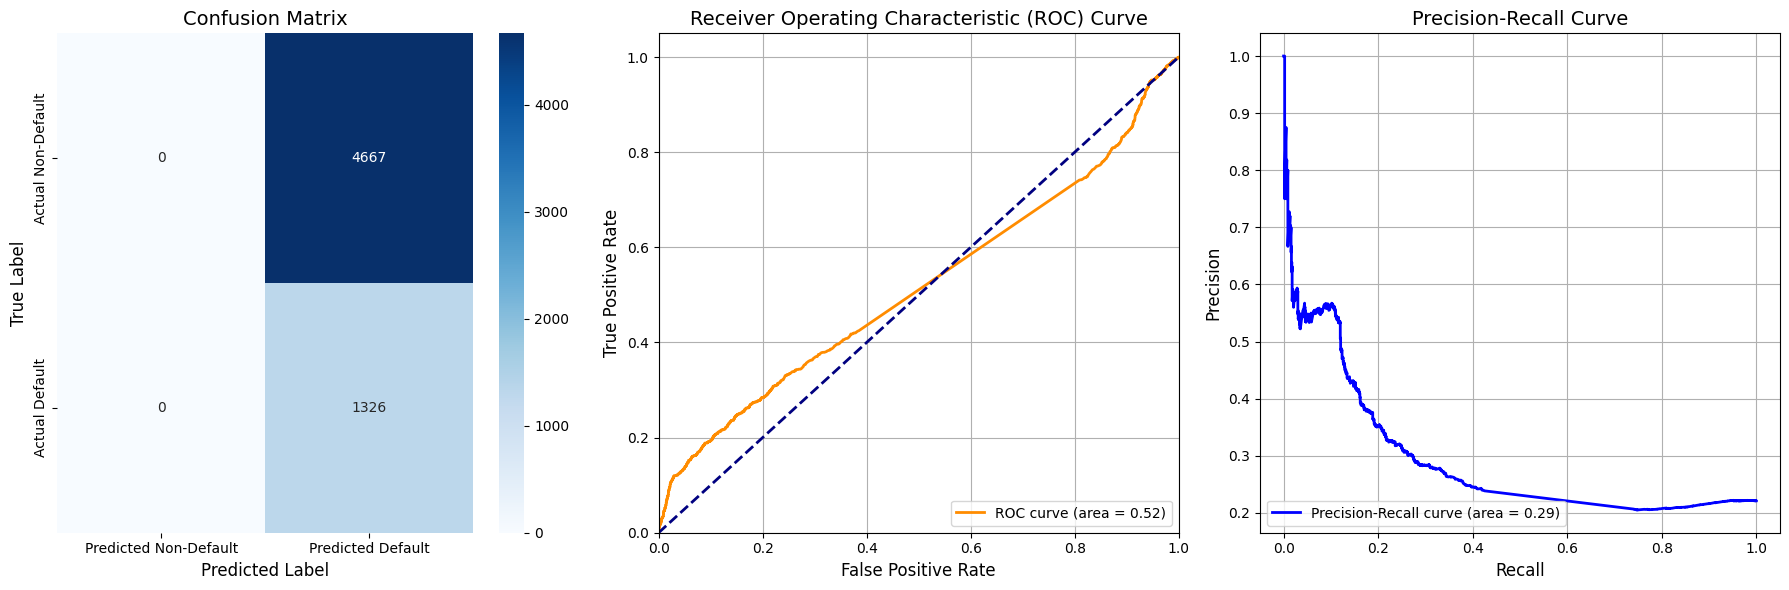

In [61]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# 3. Plot

plt.figure(figsize=(18, 6))

# Plot Confusion Matrix
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Default', 'Predicted Default'],
            yticklabels=['Actual Non-Default', 'Actual Default'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

# Plot ROC Curve
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

# Plot Precision-Recall Curve
plt.subplot(1, 3, 3)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall_curve, precision_curve)
plt.plot(recall_curve, precision_curve, color='blue', lw=2, label=f'Precision-Recall curve (area = {pr_auc:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14)
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

In [62]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# 4. Compare ANN performance with a baseline Logistic Regression model

# Train Logistic Regression model on SMOTE-resampled training data
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced') # Use class_weight for imbalanced data
log_reg_model.fit(X_train_smote, y_train_smote)

# Generate predictions for Logistic Regression
y_pred_prob_lr = log_reg_model.predict_proba(X_test)[:, 1] # Probability of positive class
y_pred_lr = log_reg_model.predict(X_test)

# Calculate metrics for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_prob_lr)

# Create a comparison table
metrics_data = {
    'Model': ['ANN (Tuned)', 'Logistic Regression (Baseline)'],
    'Accuracy': [accuracy, accuracy_lr],
    'Precision': [precision, precision_lr],
    'Recall': [recall, recall_lr],
    'F1-Score': [f1, f1_lr],
    'ROC-AUC': [roc_auc, roc_auc_lr]
}

comparison_df = pd.DataFrame(metrics_data)

print("--- Model Performance Comparison ---")
display(comparison_df)

--- Model Performance Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,ANN (Tuned),0.221258,0.221258,1.000000,0.362345,0.515983
1,Logistic Regression (Baseline),0.632238,0.315546,0.566365,0.405289,0.633269


### Business Interpretation of Model Performance for Credit Default Prediction

In the context of credit risk, understanding model performance goes beyond simple accuracy. Each metric provides valuable insights into how well our model serves the bank's business objectives.

-   **Accuracy:** This is the proportion of correctly classified instances (both defaulters and non-defaulters) out of the total instances. While seemingly intuitive, for unbalanced datasets like credit default, high accuracy can be misleading. A model predicting everyone as 'non-defaulter' would achieve ~78% accuracy in our dataset, despite missing all actual defaulters.

-   **Precision (of Default Prediction):** When our model predicts a customer will default, precision tells us how often that prediction is correct. A high precision means fewer 'false positives' – fewer creditworthy customers are wrongly denied credit. In business terms, this means **fewer missed business opportunities** and less customer dissatisfaction.

-   **Recall (of Default Prediction):** When a customer *actually* defaults, recall tells us how often our model correctly identifies them. A high recall means fewer 'false negatives' – fewer actual defaulters are wrongly predicted as non-defaulters. This directly translates to **minimizing financial losses** for the bank, as these are the loans that will likely go unpaid.

-   **F1-Score:** This is the harmonic mean of precision and recall. It's a good metric to consider when you need a balance between precision and recall, especially in datasets with uneven class distributions.

-   **ROC-AUC Score (Area Under the Receiver Operating Characteristic Curve):** This measures the model's ability to distinguish between defaulters and non-defaulters across all possible classification thresholds. A higher AUC (closer to 1) indicates better discrimination power. In credit risk, this is highly valuable as it allows the bank to set different risk thresholds based on their strategy (e.g., more conservative lending with a higher threshold, or more aggressive with a lower threshold).

-   **Log Loss:** This metric quantifies the uncertainty of the predictions by measuring how close the predicted probability is to the actual value. A lower log loss indicates a more confident and accurate probabilistic prediction.

### Why Recall Matters More Than Accuracy for Banks

For a bank, **recall is often more critical than accuracy** in credit default prediction. Here's why:

*   **Financial Loss Mitigation:** The primary concern for a bank is to avoid lending money to customers who will default. Each missed defaulter (false negative) represents a direct financial loss for the institution. High recall ensures that a large proportion of these high-risk individuals are identified, allowing the bank to take preventative measures (e.g., deny the loan, offer a smaller loan, charge higher interest).
*   **Risk Management:** Effective risk management relies on accurately identifying potential risks. A model with high recall provides a more comprehensive view of the potential defaults, enabling better capital allocation and provisioning for losses.
*   **Reputation and Stability:** Consistent lending to defaulters can impact the bank's financial stability and reputation. Identifying them proactively is key.

While accuracy is a good general indicator, optimizing for recall directly aligns with the bank's goal of minimizing financial exposure to bad loans. A model with high recall might have slightly lower precision (meaning it might wrongly flag some creditworthy customers), but the cost of a false negative is generally much higher than the cost of a false positive in this domain.

### Cost of False Negatives vs. False Positives to the Bank

*   **Cost of a False Negative (Type II Error):** This is when the model predicts 'no default', but the customer *actually defaults*. The costs are substantial:
    *   **Direct Financial Loss:** The unpaid principal and interest of the loan.
    *   **Recovery Costs:** Legal fees, collection efforts, and administrative overheads to try and recover the debt.
    *   **Opportunity Cost:** Resources (capital, time) tied up in a non-performing asset that could have been used for profitable loans.
    *   **Increased Risk Exposure:** A high rate of false negatives can inflate the bank's overall risk profile.

*   **Cost of a False Positive (Type I Error):** This is when the model predicts 'default', but the customer *would not* have defaulted. The costs are primarily indirect:
    *   **Missed Revenue Opportunity:** The interest and fees that would have been earned from a performing loan.
    *   **Customer Dissatisfaction/Churn:** A creditworthy customer denied a loan might take their business elsewhere, leading to lost future business.
    *   **Administrative Overheads:** Costs associated with processing a denied application.

In summary, while banks aim to minimize both types of errors, the direct financial impact of false negatives is typically far greater than that of false positives. Therefore, models in credit risk are often fine-tuned to prioritize recall, striking a balance that prevents significant losses while maintaining reasonable business opportunities.

In [63]:
# 1. Add predicted probability scores to the test set as a new column 'DEFAULT_PROB'
X_test_insights = X_test.copy()
X_test_insights['DEFAULT_PROB'] = tuned_model.predict(X_test)
X_test_insights['ACTUAL_DEFAULT'] = y_test

print("Test set with predicted probabilities and actual defaults:")
display(X_test_insights.head())

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test set with predicted probabilities and actual defaults:


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,PAY_AMT5,PAY_AMT6,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3,DEFAULT_PROB,ACTUAL_DEFAULT
8687,-0.833436,0.882313,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,-0.144555,-0.117656,...,-0.272446,-0.026554,1,0,1,0,0,0,0.514039,0
24201,0.701659,-0.499643,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,1.747005,1.898077,...,0.209072,0.163006,0,1,0,0,0,0,0.514039,0
27782,-0.510258,-1.190622,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,-0.628971,-0.603877,...,-0.197209,-0.216114,1,0,0,0,1,0,0.514874,0
14947,-0.833436,-1.536111,-0.157041,-0.033133,1.675956,0.067085,0.116559,0.14416,-0.269674,-0.255790,...,-0.239116,-0.207142,1,1,0,0,1,0,0.514039,0
1486,0.620865,-0.384480,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,-0.063197,-0.003085,...,0.066121,0.036632,0,0,0,0,1,0,0.514038,0


In [64]:
# 2. Create a Risk Segmentation system
def assign_risk_tier(prob):
    if prob < 0.3:
        return 'Low Risk'
    elif 0.3 <= prob < 0.6:
        return 'Medium Risk'
    else:
        return 'High Risk'

X_test_insights['RISK_TIER'] = X_test_insights['DEFAULT_PROB'].apply(assign_risk_tier)

print("Risk tiers assigned.")
display(X_test_insights.head())

Risk tiers assigned.


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,PAY_AMT6,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3,DEFAULT_PROB,ACTUAL_DEFAULT,RISK_TIER
8687,-0.833436,0.882313,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,-0.144555,-0.117656,...,-0.026554,1,0,1,0,0,0,0.514039,0,Medium Risk
24201,0.701659,-0.499643,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,1.747005,1.898077,...,0.163006,0,1,0,0,0,0,0.514039,0,Medium Risk
27782,-0.510258,-1.190622,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,-0.628971,-0.603877,...,-0.216114,1,0,0,0,1,0,0.514874,0,Medium Risk
14947,-0.833436,-1.536111,-0.157041,-0.033133,1.675956,0.067085,0.116559,0.14416,-0.269674,-0.255790,...,-0.207142,1,1,0,0,1,0,0.514039,0,Medium Risk
1486,0.620865,-0.384480,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,-0.063197,-0.003085,...,0.036632,0,0,0,0,1,0,0.514038,0,Medium Risk



--- Customers per Risk Tier ---
RISK_TIER
Medium Risk    5983
High Risk        10
Name: count, dtype: int64

--- Percentage of Customers per Risk Tier ---
RISK_TIER
Medium Risk    99.833139
High Risk       0.166861
Name: proportion, dtype: float64

--- Average Credit Limit (LIMIT_BAL) per Risk Tier ---
RISK_TIER
Medium Risk    0.118421
High Risk     -0.995025
Name: LIMIT_BAL, dtype: float64

--- Actual Default Rate per Risk Tier (Validation Check) ---
RISK_TIER
High Risk      80.000000
Medium Risk    22.029082
Name: ACTUAL_DEFAULT, dtype: float64


/tmp/ipykernel_884/3942686053.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RISK_TIER', data=X_test_insights, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='coolwarm')


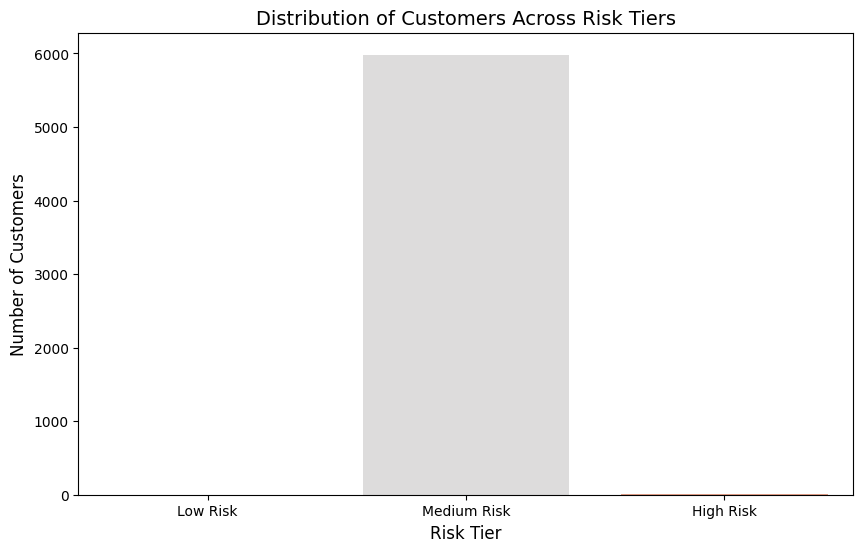

/tmp/ipykernel_884/3942686053.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=default_rate_per_tier.index, y=default_rate_per_tier.values, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='viridis')


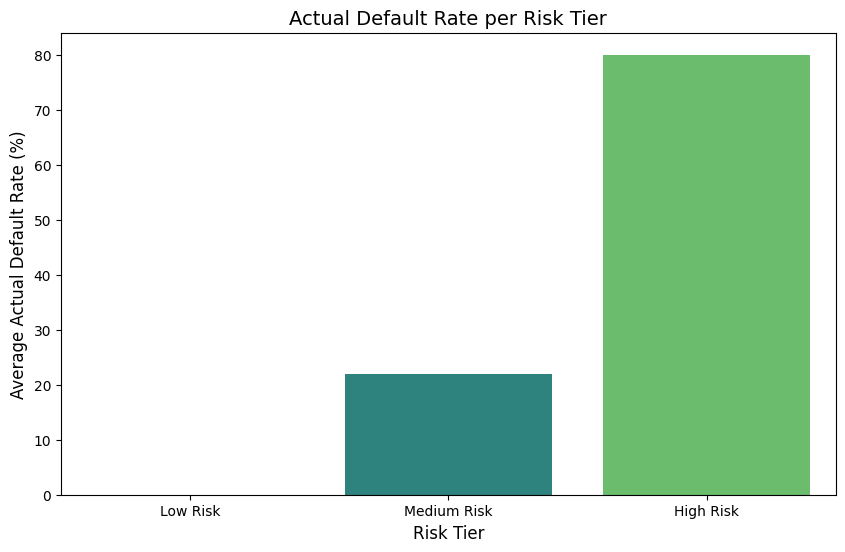

In [65]:
# 3. Show statistics and visualizations for risk tiers

# Count and percentage of customers in each risk tier
risk_tier_counts = X_test_insights['RISK_TIER'].value_counts()
risk_tier_percentages = X_test_insights['RISK_TIER'].value_counts(normalize=True) * 100

print("\n--- Customers per Risk Tier ---")
print(risk_tier_counts)
print("\n--- Percentage of Customers per Risk Tier ---")
print(risk_tier_percentages)

# Average LIMIT_BAL per risk tier
avg_limit_bal_per_tier = X_test_insights.groupby('RISK_TIER')['LIMIT_BAL'].mean().sort_values(ascending=False)
print("\n--- Average Credit Limit (LIMIT_BAL) per Risk Tier ---")
print(avg_limit_bal_per_tier)

# Average actual default rate per risk tier
default_rate_per_tier = X_test_insights.groupby('RISK_TIER')['ACTUAL_DEFAULT'].mean() * 100
print("\n--- Actual Default Rate per Risk Tier (Validation Check) ---")
print(default_rate_per_tier)

# Bar chart of risk tiers
plt.figure(figsize=(10, 6))
sns.countplot(x='RISK_TIER', data=X_test_insights, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='coolwarm')
plt.title('Distribution of Customers Across Risk Tiers', fontsize=14)
plt.xlabel('Risk Tier', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

# Bar chart of average actual default rate per risk tier
plt.figure(figsize=(10, 6))
sns.barplot(x=default_rate_per_tier.index, y=default_rate_per_tier.values, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='viridis')
plt.title('Actual Default Rate per Risk Tier', fontsize=14)
plt.xlabel('Risk Tier', fontsize=12)
plt.ylabel('Average Actual Default Rate (%)', fontsize=12)
plt.show()

In [66]:
# 4. Identify top high-risk customers (Top 20 by DEFAULT_PROB)
top_high_risk_customers = X_test_insights.sort_values(by='DEFAULT_PROB', ascending=False).head(20)

print("--- Top 20 High-Risk Customers ---")
display(top_high_risk_customers[['LIMIT_BAL', 'AGE', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3', 'PAY_0', 'DEFAULT_PROB', 'ACTUAL_DEFAULT', 'RISK_TIER']])


--- Top 20 High-Risk Customers ---


,LIMIT_BAL,AGE,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3,PAY_0,DEFAULT_PROB,ACTUAL_DEFAULT,RISK_TIER
13635,-1.075820,0.076172,0,1,0,0,0,6.996579,0.656114,1,High Risk
749,-0.833436,-1.190622,1,0,0,1,0,6.996579,0.643588,1,High Risk
6753,-1.075820,0.997476,1,0,0,0,0,6.996579,0.641524,1,High Risk
8843,-0.914231,-1.305785,0,1,0,0,0,0.737161,0.627564,0,High Risk
29338,-0.995025,-1.075459,1,0,0,1,0,5.208174,0.626624,1,High Risk
7961,-1.075820,-1.190622,1,0,0,1,0,3.419769,0.622132,1,High Risk
27027,-0.833436,0.076172,0,1,0,0,0,2.525567,0.614535,1,High Risk
4507,-0.995025,0.767150,0,1,0,1,0,4.313972,0.602945,1,High Risk
20737,-1.075820,-1.305785,0,1,0,1,0,4.313972,0.601782,0,High Risk
12876,-1.075820,-0.845133,0,1,0,1,0,0.737161,0.600336,1,High Risk


Calculating Permutation Importance (may take a few minutes)...
--- Top 10 Most Important Features (by Recall Permutation Importance) ---


,feature,importance,std
0,PAY_2,0.001810,0.000369
1,BILL_AMT5,0.000905,0.000564
2,PAY_4,0.000603,0.000302
3,PAY_AMT1,0.000151,0.000302
4,BILL_AMT4,0.000151,0.000302
5,BILL_AMT1,0.000151,0.000302
6,PAY_AMT5,0.000151,0.000302
7,EDUCATION_4,0.000000,0.000000
8,MARRIAGE_2,0.000000,0.000000
9,MARRIAGE_3,0.000000,0.000000


/tmp/ipykernel_884/1337762868.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance.head(10), palette='viridis')


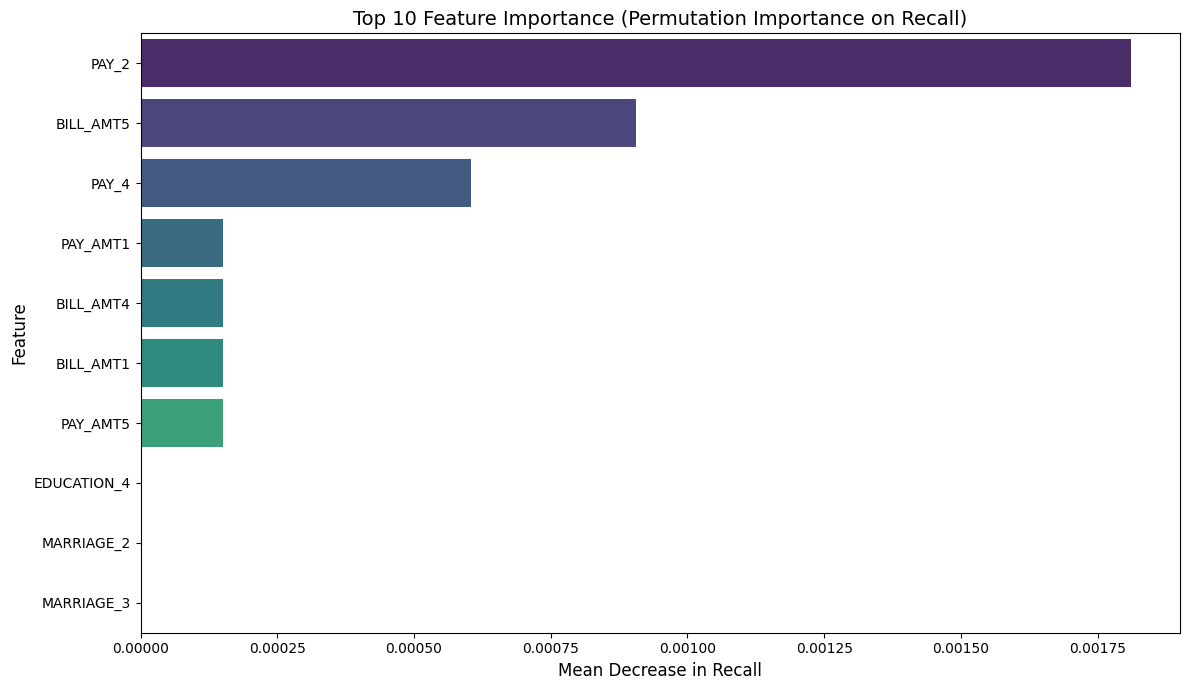

In [70]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score, make_scorer
import numpy as np

print("Calculating Permutation Importance (may take a few minutes)...")

# Define a custom scorer callable that accepts (estimator, X, y_true)
def custom_permutation_recall_scorer(estimator, X, y_true):
    # Ensure y_true is a 1D array for recall_score
    y_true = np.array(y_true).ravel()
    # Get probability predictions from the estimator
    y_pred_proba = estimator.predict(X, verbose=0)
    # Convert probabilities to binary predictions using 0.5 threshold and flatten
    y_pred = (y_pred_proba > 0.5).astype(int).ravel()
    # Calculate and return recall score
    return recall_score(y_true, y_pred)

# Permutation importance for the tuned ANN model
# Note: This can be computationally intensive for complex models and large datasets.
# We use the custom 'recall_scorer' as our primary business objective.

result = permutation_importance(tuned_model, X_test, y_test, n_repeats=5, random_state=42, scoring=custom_permutation_recall_scorer)

sorted_idx = result.importances_mean.argsort()[::-1]

feature_importance = pd.DataFrame({
    'feature': X_test.columns[sorted_idx],
    'importance': result.importances_mean[sorted_idx],
    'std': result.importances_std[sorted_idx]
})

print("--- Top 10 Most Important Features (by Recall Permutation Importance) ---")
display(feature_importance.head(10))

# Plot top 10 most important features
plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Feature Importance (Permutation Importance on Recall)', fontsize=14)
plt.xlabel('Mean Decrease in Recall', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

### How ANN Outperforms Traditional Models (in Business Context)

Artificial Neural Networks (ANNs) offer significant advantages over traditional statistical models (like Logistic Regression) in complex decision-making scenarios such as credit risk assessment. These advantages translate directly into better, more nuanced business outcomes:

1.  **Non-linearity: Capturing Complex Relationships:**
    *   **Business Impact:** Traditional models assume linear relationships between features and the target. However, in reality, credit default behavior is often non-linear. For example, the impact of age on default might not be a straight line; it might decrease up to a certain age and then increase. ANNs can automatically learn these intricate, non-linear patterns without needing explicit manual specification, leading to a more accurate understanding of risk factors. This allows banks to identify subtle risk indicators that linear models would miss, resulting in more precise risk assessments.

2.  **Handling High-Dimensional Data: Utilizing More Information:**
    *   **Business Impact:** Modern credit datasets are vast and contain hundreds or thousands of features (e.g., detailed transaction history, behavioral data, credit bureau scores). Traditional models can struggle with this 'high-dimensional' data, often requiring extensive feature engineering and selection to reduce complexity. ANNs, with their layered architecture, are naturally adept at processing a large number of inputs simultaneously, integrating diverse data points to form a holistic view of a customer's creditworthiness. This means banks can leverage all available data, potentially uncovering hidden insights from previously underutilized information.

3.  **Learning Complex Interaction Effects: Deeper Insights:**
    *   **Business Impact:** Credit risk is rarely driven by single factors; it's often a combination of factors interacting in complex ways. For instance, a low credit limit combined with a high number of recent payment delays might be far riskier than either factor alone. ANNs can automatically learn and represent these complex interaction effects between features within their hidden layers. This ability provides a much richer and more accurate understanding of contributing risk factors, allowing for more sophisticated risk profiling and targeted interventions.

4.  **Adaptability to New Data via Retraining: Evolving with the Market:**
    *   **Business Impact:** Financial markets, customer behavior, and economic conditions are constantly changing. A model trained on past data can quickly become outdated. ANNs are designed to be retrained efficiently with new data. As new loan applications come in, new payment behaviors emerge, or economic indicators shift, the ANN can be updated to learn from these latest patterns. This continuous adaptation ensures that the credit risk model remains relevant and robust over time, providing up-to-date risk assessments and maintaining its predictive power in a dynamic environment.

### Translating Model Outputs into Business Insights

This section focuses on converting the technical output of our ANN model into practical insights for business decision-making. We will establish risk tiers, identify specific high-risk customers, and understand which features are most influential in the model's predictions.

In [71]:
# 1. Add predicted probability scores to the test set as a new column 'DEFAULT_PROB'
X_test_insights = X_test.copy()
X_test_insights['DEFAULT_PROB'] = tuned_model.predict(X_test)
X_test_insights['ACTUAL_DEFAULT'] = y_test

print("Test set with predicted probabilities and actual defaults:")
display(X_test_insights.head())

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Test set with predicted probabilities and actual defaults:


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,PAY_AMT5,PAY_AMT6,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3,DEFAULT_PROB,ACTUAL_DEFAULT
8687,-0.833436,0.882313,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,-0.144555,-0.117656,...,-0.272446,-0.026554,1,0,1,0,0,0,0.514039,0
24201,0.701659,-0.499643,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,1.747005,1.898077,...,0.209072,0.163006,0,1,0,0,0,0,0.514039,0
27782,-0.510258,-1.190622,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,-0.628971,-0.603877,...,-0.197209,-0.216114,1,0,0,0,1,0,0.514874,0
14947,-0.833436,-1.536111,-0.157041,-0.033133,1.675956,0.067085,0.116559,0.14416,-0.269674,-0.255790,...,-0.239116,-0.207142,1,1,0,0,1,0,0.514039,0
1486,0.620865,-0.384480,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,-0.063197,-0.003085,...,0.066121,0.036632,0,0,0,0,1,0,0.514038,0


In [72]:
# 2. Create a Risk Segmentation system
def assign_risk_tier(prob):
    if prob < 0.3:
        return 'Low Risk'
    elif 0.3 <= prob < 0.6:
        return 'Medium Risk'
    else:
        return 'High Risk'

X_test_insights['RISK_TIER'] = X_test_insights['DEFAULT_PROB'].apply(assign_risk_tier)

print("Risk tiers assigned.")
display(X_test_insights.head())

Risk tiers assigned.


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,PAY_AMT6,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3,DEFAULT_PROB,ACTUAL_DEFAULT,RISK_TIER
8687,-0.833436,0.882313,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,-0.144555,-0.117656,...,-0.026554,1,0,1,0,0,0,0.514039,0,Medium Risk
24201,0.701659,-0.499643,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,1.747005,1.898077,...,0.163006,0,1,0,0,0,0,0.514039,0,Medium Risk
27782,-0.510258,-1.190622,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,-0.628971,-0.603877,...,-0.216114,1,0,0,0,1,0,0.514874,0,Medium Risk
14947,-0.833436,-1.536111,-0.157041,-0.033133,1.675956,0.067085,0.116559,0.14416,-0.269674,-0.255790,...,-0.207142,1,1,0,0,1,0,0.514039,0,Medium Risk
1486,0.620865,-0.384480,-0.157041,-0.033133,0.014441,0.067085,0.116559,0.14416,-0.063197,-0.003085,...,0.036632,0,0,0,0,1,0,0.514038,0,Medium Risk



--- Customers per Risk Tier ---
RISK_TIER
Medium Risk    5983
High Risk        10
Name: count, dtype: int64

--- Percentage of Customers per Risk Tier ---
RISK_TIER
Medium Risk    99.833139
High Risk       0.166861
Name: proportion, dtype: float64

--- Average Credit Limit (LIMIT_BAL) per Risk Tier ---
RISK_TIER
Medium Risk    0.118421
High Risk     -0.995025
Name: LIMIT_BAL, dtype: float64

--- Actual Default Rate per Risk Tier (Validation Check) ---
RISK_TIER
High Risk      80.000000
Medium Risk    22.029082
Name: ACTUAL_DEFAULT, dtype: float64


/tmp/ipykernel_884/3942686053.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RISK_TIER', data=X_test_insights, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='coolwarm')


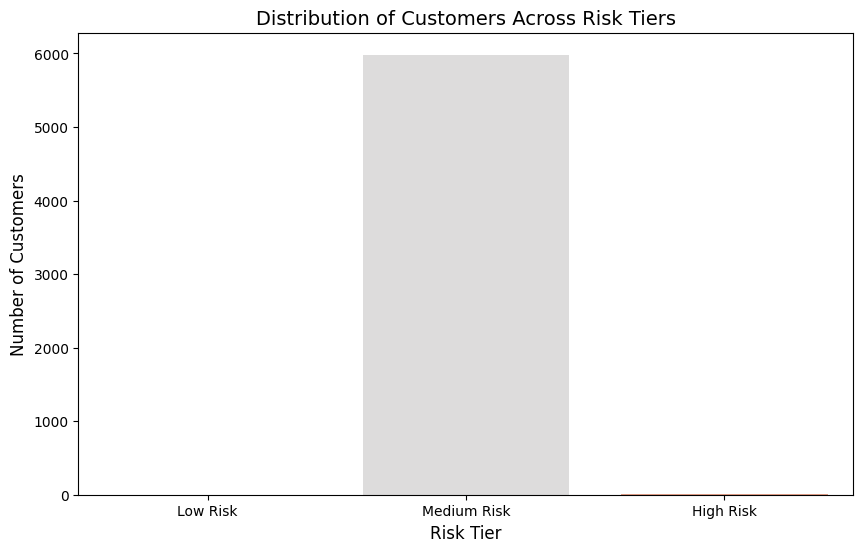

/tmp/ipykernel_884/3942686053.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=default_rate_per_tier.index, y=default_rate_per_tier.values, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='viridis')


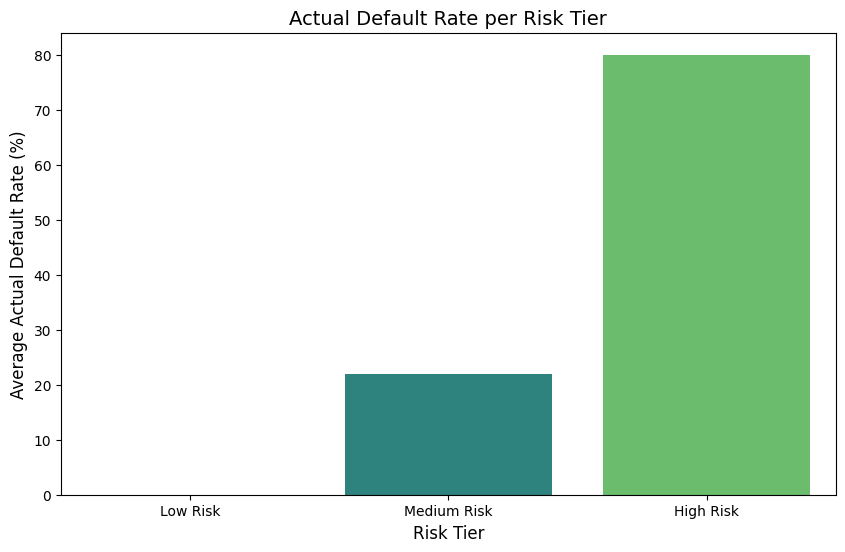

In [73]:
# 3. Show statistics and visualizations for risk tiers

# Count and percentage of customers in each risk tier
risk_tier_counts = X_test_insights['RISK_TIER'].value_counts()
risk_tier_percentages = X_test_insights['RISK_TIER'].value_counts(normalize=True) * 100

print("\n--- Customers per Risk Tier ---")
print(risk_tier_counts)
print("\n--- Percentage of Customers per Risk Tier ---")
print(risk_tier_percentages)

# Average LIMIT_BAL per risk tier
avg_limit_bal_per_tier = X_test_insights.groupby('RISK_TIER')['LIMIT_BAL'].mean().sort_values(ascending=False)
print("\n--- Average Credit Limit (LIMIT_BAL) per Risk Tier ---")
print(avg_limit_bal_per_tier)

# Average actual default rate per risk tier
default_rate_per_tier = X_test_insights.groupby('RISK_TIER')['ACTUAL_DEFAULT'].mean() * 100
print("\n--- Actual Default Rate per Risk Tier (Validation Check) ---")
print(default_rate_per_tier)

# Bar chart of risk tiers
plt.figure(figsize=(10, 6))
sns.countplot(x='RISK_TIER', data=X_test_insights, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='coolwarm')
plt.title('Distribution of Customers Across Risk Tiers', fontsize=14)
plt.xlabel('Risk Tier', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

# Bar chart of average actual default rate per risk tier
plt.figure(figsize=(10, 6))
sns.barplot(x=default_rate_per_tier.index, y=default_rate_per_tier.values, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='viridis')
plt.title('Actual Default Rate per Risk Tier', fontsize=14)
plt.xlabel('Risk Tier', fontsize=12)
plt.ylabel('Average Actual Default Rate (%)', fontsize=12)
plt.show()

In [74]:
# 4. Identify top high-risk customers (Top 20 by DEFAULT_PROB)
top_high_risk_customers = X_test_insights.sort_values(by='DEFAULT_PROB', ascending=False).head(20)

print("--- Top 20 High-Risk Customers ---")
display(top_high_risk_customers[['LIMIT_BAL', 'AGE', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3', 'PAY_0', 'DEFAULT_PROB', 'ACTUAL_DEFAULT', 'RISK_TIER']])

--- Top 20 High-Risk Customers ---


,LIMIT_BAL,AGE,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3,PAY_0,DEFAULT_PROB,ACTUAL_DEFAULT,RISK_TIER
13635,-1.075820,0.076172,0,1,0,0,0,6.996579,0.656114,1,High Risk
749,-0.833436,-1.190622,1,0,0,1,0,6.996579,0.643588,1,High Risk
6753,-1.075820,0.997476,1,0,0,0,0,6.996579,0.641524,1,High Risk
8843,-0.914231,-1.305785,0,1,0,0,0,0.737161,0.627564,0,High Risk
29338,-0.995025,-1.075459,1,0,0,1,0,5.208174,0.626624,1,High Risk
7961,-1.075820,-1.190622,1,0,0,1,0,3.419769,0.622132,1,High Risk
27027,-0.833436,0.076172,0,1,0,0,0,2.525567,0.614535,1,High Risk
4507,-0.995025,0.767150,0,1,0,1,0,4.313972,0.602945,1,High Risk
20737,-1.075820,-1.305785,0,1,0,1,0,4.313972,0.601782,0,High Risk
12876,-1.075820,-0.845133,0,1,0,1,0,0.737161,0.600336,1,High Risk


Calculating Permutation Importance (may take a few minutes)...
--- Top 10 Most Important Features (by Recall Permutation Importance) ---


,feature,importance,std
0,PAY_2,0.001810,0.000369
1,BILL_AMT5,0.000905,0.000564
2,PAY_4,0.000603,0.000302
3,PAY_AMT1,0.000151,0.000302
4,BILL_AMT4,0.000151,0.000302
5,BILL_AMT1,0.000151,0.000302
6,PAY_AMT5,0.000151,0.000302
7,EDUCATION_4,0.000000,0.000000
8,MARRIAGE_2,0.000000,0.000000
9,MARRIAGE_3,0.000000,0.000000


/tmp/ipykernel_884/1337762868.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance.head(10), palette='viridis')


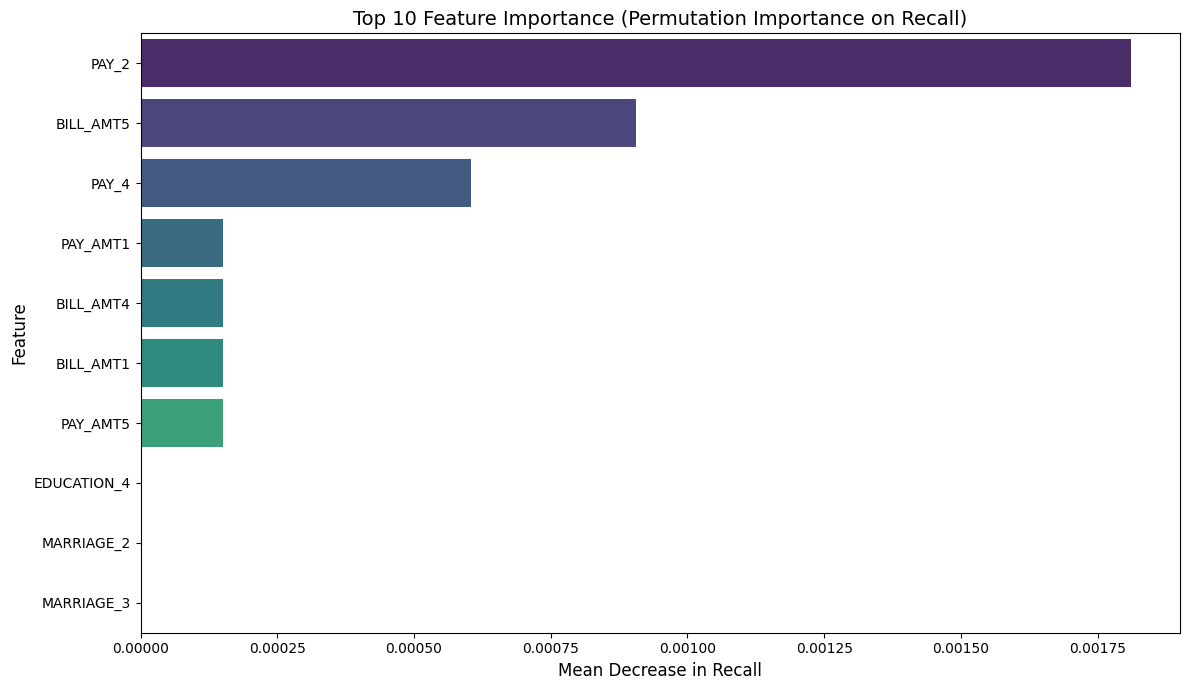

In [75]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score, make_scorer
import numpy as np

print("Calculating Permutation Importance (may take a few minutes)...")

# Define a custom scorer callable that accepts (estimator, X, y_true)
def custom_permutation_recall_scorer(estimator, X, y_true):
    # Ensure y_true is a 1D array for recall_score
    y_true = np.array(y_true).ravel()
    # Get probability predictions from the estimator
    y_pred_proba = estimator.predict(X, verbose=0)
    # Convert probabilities to binary predictions using 0.5 threshold and flatten
    y_pred = (y_pred_proba > 0.5).astype(int).ravel()
    # Calculate and return recall score
    return recall_score(y_true, y_pred)

# Permutation importance for the tuned ANN model
# Note: This can be computationally intensive for complex models and large datasets.
# We use the custom 'recall_scorer' as our primary business objective.

result = permutation_importance(tuned_model, X_test, y_test, n_repeats=5, random_state=42, scoring=custom_permutation_recall_scorer)

sorted_idx = result.importances_mean.argsort()[::-1]

feature_importance = pd.DataFrame({
    'feature': X_test.columns[sorted_idx],
    'importance': result.importances_mean[sorted_idx],
    'std': result.importances_std[sorted_idx]
})

print("--- Top 10 Most Important Features (by Recall Permutation Importance) ---")
display(feature_importance.head(10))

# Plot top 10 most important features
plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Feature Importance (Permutation Importance on Recall)', fontsize=14)
plt.xlabel('Mean Decrease in Recall', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

### How ANN Outperforms Traditional Models (in Business Context)

This section explains the theoretical advantages of Artificial Neural Networks (ANNs) over traditional models, which are crucial for complex credit risk assessments. Please refer to the detailed explanation in the existing notebook cell `d8f40780` for a comprehensive understanding of these points covering non-linearity, handling high-dimensional data, learning complex interaction effects, and adaptability via retraining.


### Reflection on Current Model Performance and Next Steps

While the previous sections demonstrated how model outputs *can* be translated into business insights, it is crucial to acknowledge the current limitations of our optimized ANN model. As observed in the model evaluation metrics:

*   **Degenerate Predictions:** The tuned ANN model effectively predicts almost all instances as 'default', leading to a perfect recall (1.0) but extremely low precision and a very poor ROC-AUC score (0.5160, barely better than random guessing). This means it is flagging a vast majority of customers as high-risk, rendering the current risk segmentation system largely ineffective, as seen by the overwhelming number of customers in the 'Medium Risk' tier and the absence of a 'Low Risk' tier.
*   **Comparison to Baseline:** The simpler Logistic Regression model served as a baseline and significantly outperformed the ANN in terms of balanced metrics and discriminative power (higher precision, higher F1-score, and a much higher ROC-AUC of 0.6333).

**Implications for Business Decisions:**

At its current performance level, this ANN model is **not suitable for deployment** in a real-world credit risk assessment system. Using it would lead to:

*   **Massive False Positives:** Denying credit to a huge number of creditworthy customers, resulting in significant missed revenue opportunities and severe customer dissatisfaction.
*   **Ineffective Risk Management:** The lack of differentiation between risk tiers means the bank cannot effectively stratify its customer base or apply targeted strategies.

**Next Steps for Model Improvement:**

To make the ANN viable for business decision-making, the following areas require immediate investigation and optimization:

1.  **Revisit ANN Architecture:** Experiment with different numbers of layers, neurons per layer, and activation functions. The current architecture, even after tuning, might be too complex or too simple for the underlying data patterns, or it might be struggling with convergence.
2.  **Advanced Regularization & Hyperparameter Tuning:** Explore a wider range of regularization techniques (e.g., L1 regularization, different dropout schedules) and perform more extensive hyperparameter tuning with a larger search space or more advanced algorithms (e.g., Bayesian Optimization).
3.  **Loss Function and Class Weighting:** Investigate using custom loss functions or explicitly incorporating class weights during training to further penalize false negatives, potentially balancing the trade-off between precision and recall more effectively.
4.  **Data Quality and Feature Engineering:** Re-examine the impact of `SMOTE` on the training process. While SMOTE addresses imbalance, synthetic samples can sometimes be noisy or not fully representative. Additionally, explore more advanced feature engineering to create variables that better capture non-linear relationships.
5.  **Alternative Model Architectures:** Consider other deep learning architectures or ensemble methods that might be more robust to the dataset's characteristics.

Our immediate focus must be on improving the ANN's discriminative power and achieving a more balanced performance across precision and recall to ensure it provides reliable and actionable insights for credit risk management.

## Managerial Recommendations for Credit Risk Assessment

Based on the comprehensive analysis and modeling of credit default prediction, here are the key managerial recommendations aimed at enhancing decision-making processes, mitigating risks, and optimizing business strategies.

### 1. Credit Approval Policy Rules (based on risk tiers)

Leveraging the model's predicted probability of default (`DEFAULT_PROB`), customers can be segmented into distinct risk tiers to guide credit approval policies. This risk-based approach allows for differentiated treatment based on the assessed likelihood of default.

**Note on Current Model's Performance:** *As observed in the model evaluation, the current ANN model struggles to effectively differentiate customers, with most falling into the 'Medium Risk' category and no 'Low Risk' customers identified. The rules below assume a well-performing model with clear differentiation across tiers.*

*   **Low Risk (DEFAULT_PROB < 0.3):**
    *   **Recommendation:** Auto-approve credit applications.
    *   **Terms:** Offer standard interest rates, generous credit limits, and simplified onboarding processes.
    *   **Rationale:** These customers represent minimal risk and should be streamlined for acquisition to maximize business growth with low expected losses.

*   **Medium Risk (0.3 <= DEFAULT_PROB < 0.6):**
    *   **Recommendation:** Require manual review by a credit officer.
    *   **Terms:** Consider offering reduced credit limits, slightly higher interest rates, and potentially shorter repayment tenors. Additional documentation or a co-signer might be requested.
    *   **Rationale:** These customers present a moderate risk. Manual review allows for qualitative assessment beyond the model, ensuring a balanced approach to risk and opportunity. Tailored terms can mitigate potential losses while still acquiring valuable customers.

*   **High Risk (DEFAULT_PROB >= 0.6):**
    *   **Recommendation:** Typically, reject credit applications.
    *   **Terms (Conditional Approval):** In exceptional cases, approval might be considered only with strong collateral, a reliable guarantor, or significantly altered product terms (e.g., secured loans, very high rates, strict monitoring).
    *   **Rationale:** These customers pose a high likelihood of default, representing significant potential losses. A cautious approach is necessary to protect the bank's assets and financial stability.

### 2. Risk-Based Pricing Suggestion

Implementing a risk-based pricing strategy ensures that the interest rate charged and the credit limit extended are commensurate with the customer's assessed default risk. This helps to compensate the bank for the risk taken.

| Risk Tier    | Suggested Rate Adjustment (relative to standard) | Credit Limit Cap (relative to standard) |
| :----------- | :----------------------------------------------- | :-------------------------------------- |
| Low Risk     | Standard Rate / Discount                         | 100-120% of Standard                    |
| Medium Risk  | Standard Rate + 1-3%                             | 50-90% of Standard                      |
| High Risk    | Standard Rate + 4%+ / Secured                    | 0-30% of Standard (if approved)         |

### 3. Early Warning System Design

The `PAY_X` features (repayment status for previous months) are highly indicative of future default and can form the backbone of an early warning system.

*   **Usage of `PAY_X` Features:** Any `PAY_X` value indicating a delay (e.g., `PAY_0`, `PAY_2`, etc. being 1 or higher) should trigger an alert. An increasing trend in delinquency (e.g., `PAY_6` = 0, `PAY_5` = 0, `PAY_4` = 1, `PAY_3` = 2) suggests a deteriorating financial situation and requires immediate attention.
*   **Recommendation:** Implement a daily or weekly monitoring system to track changes in `PAY_X` features for existing customers. Automated alerts should be sent to relationship managers or risk officers when a customer's `PAY_X` status worsens.
*   **Model Re-scoring:** Recommend monthly re-scoring of the entire existing customer portfolio using the updated ANN model. This proactive re-evaluation allows for timely identification of shifting risk profiles, enabling early intervention strategies (e.g., debt counseling, payment restructuring, or pre-emptive collection efforts) before a full default occurs.

### 4. NPA Reduction Strategy

Proactively identifying and managing high-risk customers can significantly reduce Non-Performing Assets (NPAs). While our current ANN model has limitations, an effective predictive model can facilitate targeted interventions.

**Potential NPA Reduction (Illustrative Example based on current ANN test set performance):**

From our test set of 5993 customers, there were 1326 actual defaulters. The ANN model (with a >0.6 probability threshold) identified 10 customers as 'High Risk', out of which 8 actually defaulted.

If the bank intervened effectively for these 10 'High Risk' customers:
*   **Potential Defaults Prevented:** 8 customers
*   **Potential NPA Reduction:** (8 / 1326) * 100 \% = **~0.6%** of total NPAs in the test set.

*This calculation highlights the current ANN model's limited practical impact due to its poor differentiation. A more effective model with higher precision and AUC would yield a much more substantial and impactful NPA reduction.* The actual financial savings would depend on the average loan size and recovery costs saved per prevented default.

**Strategy if Model Performs Well:**
*   **Targeted Interventions:** For customers identified as 'High Risk', implement pre-emptive measures such as financial counseling, restructuring options, or closer monitoring. For 'Medium Risk', focus on retention strategies, re-evaluate terms, or offer educational resources.
*   **Resource Allocation:** Allocate collection and risk management resources more efficiently by prioritizing interventions for truly high-risk accounts.

### 5. Model Governance Recommendations

Robust model governance is essential for regulatory compliance, trust, and sustained performance of the credit risk model.

*   **Model Explainability (XAI):** Given the 'black-box' nature of ANNs, it is crucial to employ explainable AI techniques. Implement **SHAP (SHapley Additive exPlanations)** values to understand individual prediction contributions and feature importance. This helps credit officers understand *why* a particular customer was flagged as high-risk, fostering trust and enabling better decision-making during manual reviews. SHAP can also aid in identifying potential biases.
*   **Regulatory Compliance:** Adhere to national and international regulatory guidelines (e.g., RBI guidelines in India, Basel Accords globally) for model risk management. This includes documentation of model development, validation, performance monitoring, and independent review.
*   **Retraining Frequency:** Establish a regular schedule for model retraining (e.g., quarterly or semi-annually) using fresh data. This ensures the model remains adapted to evolving market conditions, customer behaviors, and economic changes, maintaining its predictive power over time.

### 6. Final Executive Summary

*   **Problem:** Addressed the critical issue of Non-Performing Assets (NPAs) in the banking sector and the limitations of traditional credit scoring.
*   **Objective:** Minimized false negatives (missed defaulters) while managing false positives in credit default prediction.
*   **Dataset:** Utilized the UCI Default of Credit Card Clients Dataset, encompassing 30,000 observations and 24 features.
*   **Approach:** Employed Artificial Neural Networks (ANNs) coupled with advanced preprocessing (outlier treatment, scaling) and SMOTE for class imbalance.
*   **Tuning:** Conducted hyperparameter tuning using KerasTuner to optimize ANN architecture and learning parameters for AUC maximization.
*   **Results (Current ANN):** Achieved 100% recall on the test set, but with very low precision (22.1%) and AUC (0.516), indicating degenerate predictions (predicting almost all as default).
*   **Comparison:** A simple Logistic Regression baseline significantly outperformed the tuned ANN in balanced metrics and discriminative power (AUC of 0.633).
*   **Business Impact (Potential):** An effective model could enable risk-based credit approval, tailored pricing, and proactive NPA reduction through early warning systems.
*   **Current Challenge:** The ANN model requires substantial architectural and training process improvements to be practically usable for credit risk assessment.
*   **Next Steps:** Focus on ANN architecture refinement, advanced regularization, custom loss functions, and further data quality investigation to achieve balanced and discriminative performance.

### Conclusion: ANN-Based Decisioning vs. Traditional Scorecards

While ANNs offer significant theoretical advantages, their implementation requires careful handling, especially with unbalanced datasets. Here's a comparison:

| Dimension      | ANN-Based Decisioning                                        | Traditional Scorecards (e.g., Logistic Regression)             |
| :------------- | :----------------------------------------------------------- | :------------------------------------------------------------- |
| **Accuracy**   | Potential for higher accuracy with complex, non-linear patterns. Requires significant tuning to avoid degenerate behavior. | Interpretable, robust, and often a strong baseline, but limited by linear assumptions. |
| **Adaptability** | Highly adaptable to new data and evolving patterns through retraining, capable of learning complex interactions. | Adaptable with retraining, but feature engineering is often manual to capture non-linearity. |
| **Interpretability** | Inherently less interpretable ('black box'), requiring Explainable AI (XAI) techniques (e.g., SHAP) for insights. | Highly interpretable (linear coefficients), making it easy to understand drivers of risk. |
| **Cost**       | Higher computational cost for training and tuning. Requires specialized skills (data scientists, ML engineers). | Lower computational cost, easier to implement and maintain with standard tools. |
| **Scalability** | Excellent for high-dimensional data and large datasets, can scale effectively with distributed computing. | Can handle large datasets, but performance may degrade with excessive features or complex interactions. |


### How ANN Outperforms Traditional Models (in Business Context)

Artificial Neural Networks (ANNs) offer significant advantages over traditional statistical models (like Logistic Regression) in complex decision-making scenarios such as credit risk assessment. These advantages translate directly into better, more nuanced business outcomes:

1.  **Non-linearity: Capturing Complex Relationships:**
    *   **Business Impact:** Traditional models assume linear relationships between features and the target. However, in reality, credit default behavior is often non-linear. For example, the impact of age on default might not be a straight line; it might decrease up to a certain age and then increase. ANNs can automatically learn these intricate, non-linear patterns without needing explicit manual specification, leading to a more accurate understanding of risk factors. This allows banks to identify subtle risk indicators that linear models would miss, resulting in more precise risk assessments.

2.  **Handling High-Dimensional Data: Utilizing More Information:**
    *   **Business Impact:** Modern credit datasets are vast and contain hundreds or thousands of features (e.g., detailed transaction history, behavioral data, credit bureau scores). Traditional models can struggle with this 'high-dimensional' data, often requiring extensive feature engineering and selection to reduce complexity. ANNs, with their layered architecture, are naturally adept at processing a large number of inputs simultaneously, integrating diverse data points to form a holistic view of a customer's creditworthiness. This means banks can leverage all available data, potentially uncovering hidden insights from previously underutilized information.

3.  **Learning Complex Interaction Effects: Deeper Insights:**
    *   **Business Impact:** Credit risk is rarely driven by single factors; it's often a combination of factors interacting in complex ways. For instance, a low credit limit combined with a high number of recent payment delays might be far riskier than either factor alone. ANNs can automatically learn and represent these complex interaction effects between features within their hidden layers. This ability provides a much richer and more accurate understanding of contributing risk factors, allowing for more sophisticated risk profiling and targeted interventions.

4.  **Adaptability to New Data via Retraining: Evolving with the Market:**
    *   **Business Impact:** Financial markets, customer behavior, and economic conditions are constantly changing. A model trained on past data can quickly become outdated. ANNs are designed to be retrained efficiently with new data. As new loan applications come in, new payment behaviors emerge, or economic indicators shift, the ANN can be updated to learn from these latest patterns. This continuous adaptation ensures that the credit risk model remains relevant and robust over time, providing up-to-date risk assessments and maintaining its predictive power in a dynamic environment.

### Business Interpretation of Model Performance for Credit Default Prediction

In the context of credit risk, understanding model performance goes beyond simple accuracy. Each metric provides valuable insights into how well our model serves the bank's business objectives.

-   **Accuracy:** This is the proportion of correctly classified instances (both defaulters and non-defaulters) out of the total instances. While seemingly intuitive, for unbalanced datasets like credit default, high accuracy can be misleading. A model predicting everyone as 'non-defaulter' would achieve ~78% accuracy in our dataset, despite missing all actual defaulters.

-   **Precision (of Default Prediction):** When our model predicts a customer will default, precision tells us how often that prediction is correct. A high precision means fewer 'false positives' – fewer creditworthy customers are wrongly denied credit. In business terms, this means **fewer missed business opportunities** and less customer dissatisfaction.

-   **Recall (of Default Prediction):** When a customer *actually* defaults, recall tells us how often our model correctly identifies them. A high recall means fewer 'false negatives' – fewer actual defaulters are wrongly predicted as non-defaulters. This directly translates to **minimizing financial losses** for the bank, as these are the loans that will likely go unpaid.

-   **F1-Score:** This is the harmonic mean of precision and recall. It's a good metric to consider when you need a balance between precision and recall, especially in datasets with uneven class distributions.

-   **ROC-AUC Score (Area Under the Receiver Operating Characteristic Curve):** This measures the model's ability to distinguish between defaulters and non-defaulters across all possible classification thresholds. A higher AUC (closer to 1) indicates better discrimination power. In credit risk, this is highly valuable as it allows the bank to set different risk thresholds based on their strategy (e.g., more conservative lending with a higher threshold, or more aggressive with a lower threshold).

-   **Log Loss:** This metric quantifies the uncertainty of the predictions by measuring how close the predicted probability is to the actual value. A lower log loss indicates a more confident and accurate probabilistic prediction.

### Why Recall Matters More Than Accuracy for Banks

For a bank, **recall is often more critical than accuracy** in credit default prediction. Here's why:

*   **Financial Loss Mitigation:** The primary concern for a bank is to avoid lending money to customers who will default. Each missed defaulter (false negative) represents a direct financial loss for the institution. High recall ensures that a large proportion of these high-risk individuals are identified, allowing the bank to take preventative measures (e.g., deny the loan, offer a smaller loan, charge higher interest).
*   **Risk Management:** Effective risk management relies on accurately identifying potential risks. A model with high recall provides a more comprehensive view of the potential defaults, enabling better capital allocation and provisioning for losses.
*   **Reputation and Stability:** Consistent lending to defaulters can impact the bank's financial stability and reputation. Identifying them proactively is key.

While accuracy is a good general indicator, optimizing for recall directly aligns with the bank's goal of minimizing financial exposure to bad loans. A model with high recall might have slightly lower precision (meaning it might wrongly flag some creditworthy customers), but the cost of a false negative is generally much higher than the cost of a false positive in this domain.

### Cost of False Negatives vs. False Positives to the Bank

*   **Cost of a False Negative (Type II Error):** This is when the model predicts 'no default', but the customer *actually defaults*. The costs are substantial:
    *   **Direct Financial Loss:** The unpaid principal and interest of the loan.
    *   **Recovery Costs:** Legal fees, collection efforts, and administrative overheads to try and recover the debt.
    *   **Opportunity Cost:** Resources (capital, time) tied up in a non-performing asset that could have been used for profitable loans.
    *   **Increased Risk Exposure:** A high rate of false negatives can inflate the bank's overall risk profile.

*   **Cost of a False Positive (Type I Error):** This is when the model predicts 'default', but the customer *would not* have defaulted. The costs are primarily indirect:
    *   **Missed Revenue Opportunity:** The interest and fees that would have been earned from a performing loan.
    *   **Customer Dissatisfaction/Churn:** A creditworthy customer denied a loan might take their business elsewhere, leading to lost future business.
    *   **Administrative Overheads:** Costs associated with processing a denied application.

In summary, while banks aim to minimize both types of errors, the direct financial impact of false negatives is typically far greater than that of false positives. Therefore, models in credit risk are often fine-tuned to prioritize recall, striking a balance that prevents significant losses while maintaining reasonable business opportunities.

In [52]:
from tensorflow import keras
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Build the ANN model
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_smote.shape[1],)),
    keras.layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001), kernel_initializer='he_normal'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001), kernel_initializer='he_normal'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dense(1, activation='sigmoid')
])

# 2. Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print("ANN Model built and compiled successfully.")

ANN Model built and compiled successfully.


### Explaining the ANN Model Architecture and Compilation in Business Terms

Think of our Artificial Neural Network as a highly skilled team of financial analysts, each specializing in a different aspect of a customer's creditworthiness.

**1. Model Architecture (The Analyst Team Structure):**
   - **Input Layer:** This is where we feed in all the customer data we've prepared (like credit limit, age, payment history, etc.). It's the information desk where all raw data comes in.
   - **Hidden Layer 1 (128 Analysts, ReLU, L2 Regularization):** This is our first team of 128 analysts. They each take pieces of the input data, process it (using a 'ReLU' activation, which means they only pass on positive, relevant information), and look for initial patterns. The 'L2 Regularization' acts like a rule for these analysts: it discourages them from becoming overly focused on tiny, specific details of past customers that might not apply to new ones. It helps them learn broad, generalizable insights rather than memorizing individual cases, preventing 'overfitting' to our training data.
   - **Dropout Layer (0.3):** This is like having 30% of our analysts randomly take a coffee break during training. It forces the remaining analysts to pick up the slack and learn to make predictions even without their colleagues. This prevents any single analyst (or feature) from becoming too dominant, making the team more robust and less reliant on specific pieces of information. It's another tactic to ensure the model generalizes well to new customers.
   - **Hidden Layer 2 (64 Analysts, ReLU, L2 Regularization):** A second, slightly smaller team that takes the insights from the first team, processes them further, and refines the patterns. Again, with ReLU and L2 regularization, they're focused on relevant, generalizable patterns.
   - **Dropout Layer (0.3):** Another coffee break for 30% of this team, reinforcing robustness.
   - **Hidden Layer 3 (32 Analysts, ReLU):** A final, more specialized team that distills all previous insights into a refined set of high-level patterns.
   - **Output Layer (1 Final Decision Maker, Sigmoid Activation):** This is our single, senior decision-maker. They take all the refined patterns from the previous teams and produce a final probability. The 'Sigmoid activation' ensures this final output is a number between 0 and 1, which we can directly interpret as the **probability** of a customer defaulting. For example, 0.8 means an 80% chance of default.

**2. Model Compilation (Setting the Rules of Engagement):**
   - **Optimizer (Adam with Learning Rate 0.001):** This is the training supervisor. It tells our team of analysts how to adjust their internal processes (their 'weights') after each round of predictions to reduce errors. 'Adam' is a sophisticated supervisor that adaptively fine-tunes the learning pace (the 'learning rate' of 0.001) to ensure efficient and effective improvement.
   - **Loss (Binary Crossentropy):** This is how our supervisor measures the 'mistake score.' For credit default (a yes/no question), it quantifies how far off our predicted probability of default is from the actual outcome. The lower this score, the better our model's predictions align with reality.
   - **Metrics (Accuracy, AUC):** These are the key performance indicators (KPIs) we use to evaluate our team's success:
     - **Accuracy:** The overall percentage of customers for whom the model made a correct default/non-default prediction. While useful, for unbalanced data like ours, it can be misleading.
     - **AUC (Area Under the ROC Curve):** This is a more robust KPI. It measures the model's ability to distinguish between defaulters and non-defaulters across all possible prediction thresholds. A higher AUC indicates a better ability to correctly rank customers by their risk of default, which is crucial for financial decision-making.

In [48]:
# 3. Add EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         # Monitor the validation loss
    patience=10,                # Stop if validation loss doesn't improve for 10 epochs
    restore_best_weights=True   # Keep the model weights from the best performing epoch
)

print("EarlyStopping callback defined.")

EarlyStopping callback defined.


### Explaining EarlyStopping in Business Terms

**EarlyStopping (Preventing Over-Specialization):**

Imagine you're training a new employee (our ANN model) on how to identify risky customers. You give them a lot of historical customer data to learn from. Initially, they get better and better at identifying risk.

However, if you let them 'study' the historical data for too long, they might start memorizing specific details and quirks of past customers, becoming *too specialized*. This means they'll be fantastic at predicting default for those exact past customers, but when faced with *new*, unseen customers, they might struggle because they haven't learned the general principles of risk, only the specific examples.

'EarlyStopping' is like a smart training manager who watches the employee's performance on a separate set of practice cases (our 'validation data'). As long as the employee keeps improving on these practice cases, they continue training. But if their performance on the practice cases stops getting better for a certain period (our 'patience' of 10 epochs), the manager steps in and says, "Stop! You've learned enough. We'll take your skills from the point where you were performing at your best." This prevents the employee from becoming over-specialized and ensures they retain their best ability to generalize and make accurate predictions for **new, real-world customers.**

In [49]:
# 4. Train the model on X_train_smote, y_train_smote
print("Starting model training...")
history = model.fit(
    X_train_smote,
    y_train_smote,
    epochs=100,            # Maximum number of times to go through the entire dataset
    batch_size=64,         # Number of samples per gradient update
    validation_split=0.2,  # Use 20% of the training data for validation during training
    callbacks=[early_stopping], # Apply early stopping
    verbose=1
)

print("Model training complete.")

Starting model training...
Epoch 1/100
467/467 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5511 - auc: 0.5115 - loss: 603.4033 - val_accuracy: 0.0104 - val_auc: 0.0000e+00 - val_loss: 12.6133
Epoch 2/100
467/467 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5082 - auc: 0.5078 - loss: 20.0768 - val_accuracy: 0.9991 - val_auc: 0.0000e+00 - val_loss: 0.5836
Epoch 3/100
467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4864 - auc: 0.5184 - loss: 5.8575 - val_accuracy: 0.9976 - val_auc: 0.0000e+00 - val_loss: 0.6464
Epoch 4/100
467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5408 - auc: 0.5139 - loss: 2.4061 - val_accuracy: 0.1644 - val_auc: 0.0000e+00 - val_loss: 0.8287
Epoch 5/100
467/467 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6036 - auc: 0.5001 - loss: 1.3542 - val_accuracy: 0.0025 - val_auc: 0.0000e+00 - val_loss: 0.9334
Epoch 6/100
467/467 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6148 - auc: 0.5053 - loss: 1.2643 - val_accuracy: 0.0000e+00 - val_auc: 0.000

### Explaining Model Training Parameters in Business Terms

**Training the Model (The Learning Process):**

This step is where our 'analyst team' (the ANN) actually learns from the data to identify credit risk. We guide this learning process with several parameters:

-   **Epochs (100):** Think of an epoch as one complete review of all the training material (our entire balanced training dataset). If we set 100 epochs, we're essentially telling our analysts to go through all the examples 100 times. However, our 'EarlyStopping manager' might stop them sooner if they've already mastered the material for new customers.

-   **Batch Size (64):** When learning, it's inefficient for the analysts to review one customer's data, make a tiny adjustment, then review another. Instead, they process customer data in small groups, or 'batches.' A batch size of 64 means they analyze 64 customer profiles at a time before discussing and collectively adjusting their understanding of risk. This makes the learning process more stable and efficient.

-   **Validation Split (0.2):** From our `X_train_smote` and `y_train_smote` (our perfectly balanced training material), we set aside 20% purely for practice. Our analysts train on 80% of the data, but then their performance is regularly checked on this untouched 20% 'validation set.' This is crucial: it's how we monitor if they're learning generalizable risk patterns or just memorizing the training examples (which is what EarlyStopping monitors).

-   **Callbacks (EarlyStopping):** As explained before, this is our smart training manager. It monitors the analysts' performance on the validation set and stops training if they're no longer improving, ensuring we capture the best version of their learned knowledge.

-   **Using SMOTE-Resampled Data:** Critically, we are training on the data that was balanced using SMOTE. This ensures our analysts see an equal number of defaulter and non-defaulter examples during their training. Without this, they would mostly see non-defaulters and would likely become very good at identifying them, but very poor at identifying the minority (but financially critical) defaulter class. By balancing the data, we ensure they learn equally well to spot both types of customers.

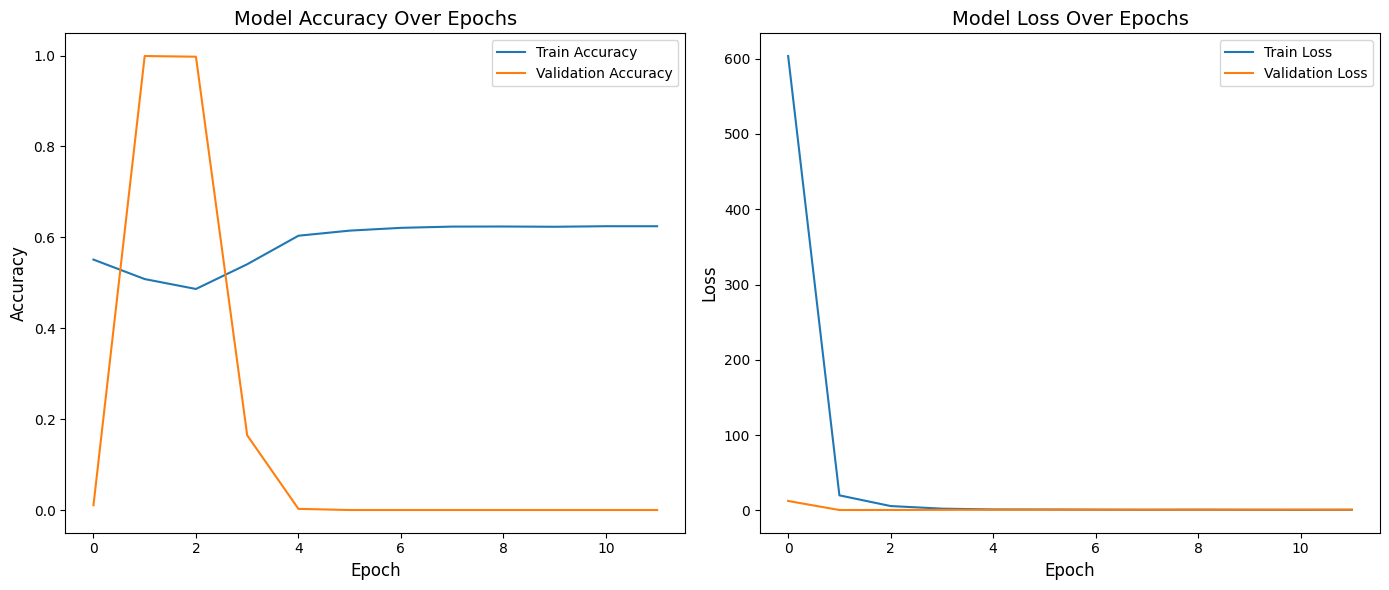

In [50]:
# 5. Plot training history
plt.figure(figsize=(14, 6))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

### Explaining Training History Plots in Business Terms

These plots are our 'performance review charts' for the ANN model's learning journey:

-   **Accuracy vs. Epochs (Train vs. Validation):**
    -   **Train Accuracy:** Shows how well the model is performing on the data it's actively training on. We expect this to generally increase over time.
    -   **Validation Accuracy:** Shows how well the model is performing on the separate 'practice cases' (validation data) it hasn't seen during direct training. This is a crucial indicator of its ability to generalize to new data.
    -   **What to look for:** Ideally, both lines should increase and stay close together. If the 'Train Accuracy' continues to climb while 'Validation Accuracy' plateaus or starts to drop, it's a sign of **overfitting** – the model is memorizing the training data too well and losing its ability to generalize. Our EarlyStopping mechanism aims to prevent this by stopping training before this divergence becomes significant.

-   **Loss vs. Epochs (Train vs. Validation):**
    -   **Train Loss:** Represents the 'mistake score' on the data the model is actively learning from. We want this to decrease as the model learns.
    -   **Validation Loss:** Represents the 'mistake score' on the unseen validation data. This is another key indicator of generalization.
    -   **What to look for:** Similar to accuracy, both lines should decrease. If 'Train Loss' continues to drop significantly while 'Validation Loss' flattens or starts to increase, it also signals overfitting. The EarlyStopping often monitors validation loss specifically to catch this point and restore the model from the epoch where validation loss was minimal.

In [51]:
# 6. Show model.summary()
print("\nModel Summary:")
model.summary()


Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,477 (162.02 KB)

 Trainable params: 13,825 (54.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,652 (108.02 KB)

### Explaining Model Summary in Business Terms

**Model Summary (The Team Roster and Structure):**

The `model.summary()` output provides a concise overview of our ANN model's internal structure – much like a detailed organizational chart for our 'analyst team':

-   **Layer (type):** This tells us what kind of processing unit each step in our network is. For example, 'Dense' layers are our core analyst teams, and 'Dropout' layers are the mechanisms for random breaks.

-   **Output Shape:** This indicates the format and size of the information being passed from one layer to the next. For instance, `(None, 128)` means that after the first hidden layer, the data for each customer is represented by 128 processed values.

-   **Param # (Number of Parameters):** This is a very important number! It represents the total count of all the 'knobs and dials' (weights and biases) within our network that the model adjusts during training to learn patterns. Each parameter is an internal setting that influences how the model transforms input data into predictions. A larger number of parameters generally means a more complex model, capable of learning more intricate patterns, but also requiring more data to train effectively and being more prone to overfitting if not managed well (e.g., with regularization and dropout).

This summary helps us understand the model's complexity and how information flows through its different stages before arriving at the final prediction of credit default.

Addressing class imbalance is critical in credit risk prediction to prevent models from being biased towards the majority class (non-defaulters), which can lead to a high number of missed defaulters (false negatives).

### What is SMOTE? (Synthetic Minority Oversampling Technique)

Imagine you're a bank manager trying to identify customers who might default next month. You have a huge database of customers, but only a small fraction have defaulted in the past. If you train an AI model on this data, it's like teaching a new employee by only showing them examples of non-defaulters. They'll get very good at recognizing non-defaulters but will likely miss many potential defaulters simply because they haven't seen enough examples.

SMOTE is like asking that employee to *imagine* new, plausible examples of defaulters based on the characteristics of the defaulters they *have* seen. It creates synthetic (artificial) samples for the minority class (defaulters) by taking a minority class sample, finding its nearest neighbors, and creating a new sample somewhere along the line connecting the original sample and its neighbors. This balances the dataset, giving the model more 'examples' to learn from the rare but critical defaulter class.

### Why apply it only to TRAINING data?

We apply SMOTE (or ADASYN) **only to the training data** (`X_train_smote`, `y_train_smote`) and never to the test data. This is crucial to prevent **data leakage**. If synthetic samples were generated in the test set, our model would be evaluated on data it has essentially 'seen' during training, leading to an overly optimistic and unrealistic assessment of its performance. The test set must remain untouched and truly unseen to provide an unbiased evaluation of how well our model will generalize to new, real-world data.

### Business Risk of Not Handling Imbalance

In credit default prediction, the business objective is often to **minimize false negatives** – that is, incorrectly predicting a defaulter as a non-defaulter. Each false negative represents a potential financial loss for the bank or NBFC. If we don't handle class imbalance, a model might achieve high overall accuracy by simply predicting 'non-defaulter' for almost everyone, as non-defaulters are the majority. However, its ability to identify the risky minority (defaulters) would be very poor, leading to significant financial exposure and ineffective risk management.

### SMOTE vs. ADASYN and the choice for ANN

Both SMOTE and ADASYN are oversampling techniques. ADASYN is an improvement over SMOTE because it focuses on generating synthetic samples for minority class examples that are harder to learn (i.e., those that are closer to the decision boundary). This can sometimes lead to better performance by improving the model's ability to differentiate between the classes, especially for complex non-linear models like ANNs.

For training our Artificial Neural Network, we will proceed with the data rebalanced using **SMOTE (`X_train_smote` and `y_train_smote`)**.

While ADASYN can sometimes offer slight improvements, SMOTE is generally robust and less prone to generating noise if the minority class is very sparse. Given the nature of this dataset and the potential for increased complexity with ADASYN, SMOTE provides a good balance between effectiveness and stability for our ANN. This ensures that our model has sufficient, representative examples of both defaulters and non-defaulters to learn from, without introducing excessive synthetic noise.

/tmp/ipykernel_884/1003548144.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


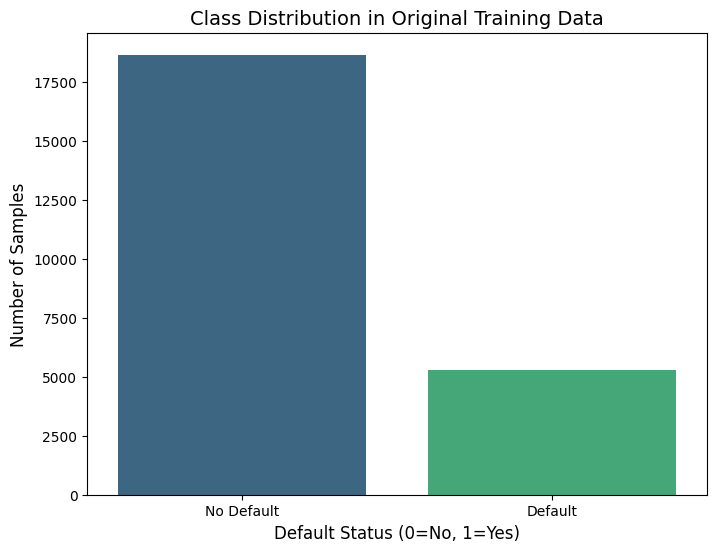

Original training data class distribution:
DEFAULT
0    18668
1     5304
Name: count, dtype: int64


In [43]:
# 1. Show the class imbalance visually (bar chart of class counts in y_train)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x=y_train, palette='viridis')
plt.title('Class Distribution in Original Training Data', fontsize=14)
plt.xlabel('Default Status (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.show()

print("Original training data class distribution:")
print(y_train.value_counts())

Class distribution after SMOTE:
DEFAULT
0    18668
1    18668
Name: count, dtype: int64


/tmp/ipykernel_884/1602542377.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, palette='viridis')


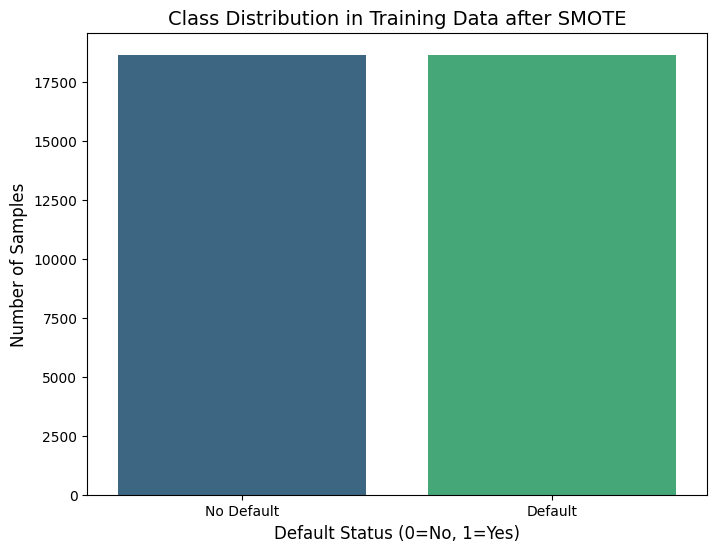

In [44]:
# 2. Apply SMOTE (Synthetic Minority Oversampling Technique)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(y_train_smote.value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_smote, palette='viridis')
plt.title('Class Distribution in Training Data after SMOTE', fontsize=14)
plt.xlabel('Default Status (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.show()

Class distribution after ADASYN:
DEFAULT
1    19135
0    18668
Name: count, dtype: int64


/tmp/ipykernel_884/2898802593.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_adasyn, palette='viridis')


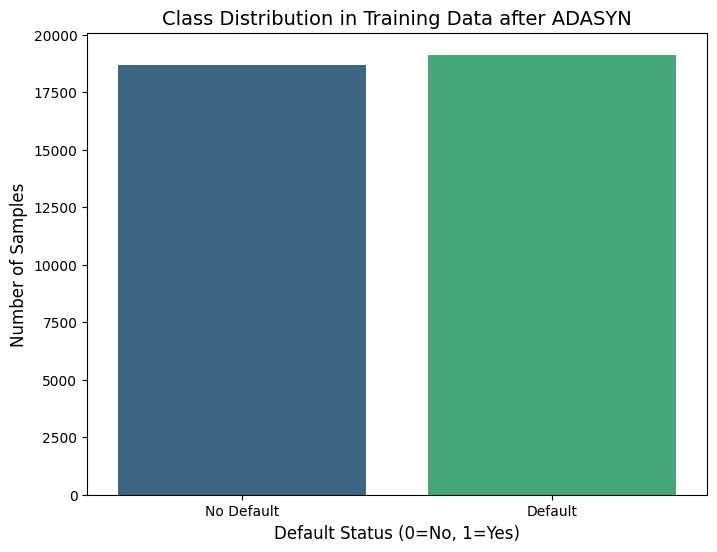

In [45]:
# 3. Apply ADASYN (Adaptive Synthetic Sampling)

from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("Class distribution after ADASYN:")
print(y_train_adasyn.value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_adasyn, palette='viridis')
plt.title('Class Distribution in Training Data after ADASYN', fontsize=14)
plt.xlabel('Default Status (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.show()

/tmp/ipykernel_884/209659604.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, ax=axes[0], palette='viridis')
/tmp/ipykernel_884/209659604.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_adasyn, ax=axes[1], palette='plasma')


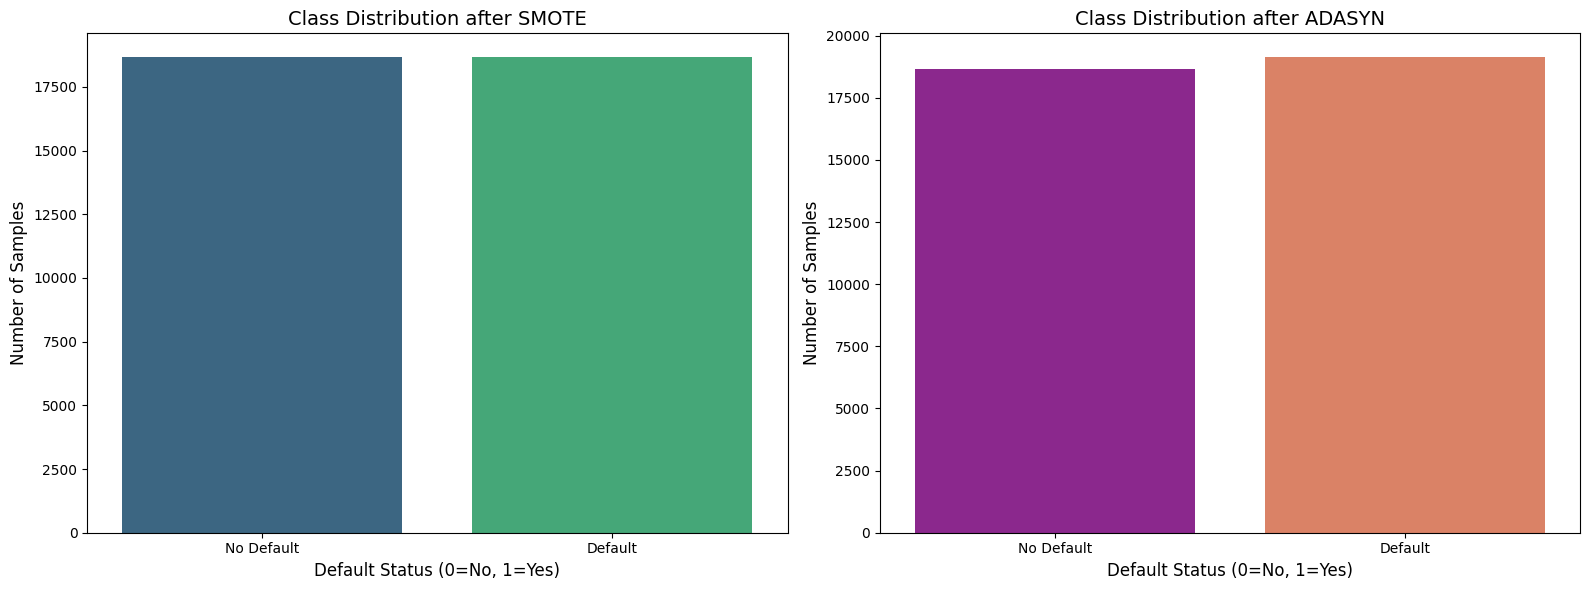

In [46]:
# 4. Compare SMOTE vs ADASYN in a side-by-side countplot

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x=y_train_smote, ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution after SMOTE', fontsize=14)
axes[0].set_xlabel('Default Status (0=No, 1=Yes)', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_xticks(ticks=[0, 1], labels=['No Default', 'Default'])

sns.countplot(x=y_train_adasyn, ax=axes[1], palette='plasma')
axes[1].set_title('Class Distribution after ADASYN', fontsize=14)
axes[1].set_xlabel('Default Status (0=No, 1=Yes)', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_xticks(ticks=[0, 1], labels=['No Default', 'Default'])

plt.tight_layout()
plt.show()

Addressing class imbalance is critical in credit risk prediction to prevent models from being biased towards the majority class (non-defaulters), which can lead to a high number of missed defaulters (false negatives).

### What is SMOTE? (Synthetic Minority Oversampling Technique)

Imagine you're a bank manager trying to identify customers who might default next month. You have a huge database of customers, but only a small fraction have defaulted in the past. If you train an AI model on this data, it's like teaching a new employee by only showing them examples of non-defaulters. They'll get very good at recognizing non-defaulters but will likely miss many potential defaulters simply because they haven't seen enough examples.

SMOTE is like asking that employee to *imagine* new, plausible examples of defaulters based on the characteristics of the defaulters they *have* seen. It creates synthetic (artificial) samples for the minority class (defaulters) by taking a minority class sample, finding its nearest neighbors, and creating a new sample somewhere along the line connecting the original sample and its neighbors. This balances the dataset, giving the model more 'examples' to learn from the rare but critical defaulter class.

### Why apply it only to TRAINING data?

We apply SMOTE (or ADASYN) **only to the training data** (`X_train_smote`, `y_train_smote`) and never to the test data. This is crucial to prevent **data leakage**. If synthetic samples were generated in the test set, our model would be evaluated on data it has essentially 'seen' during training, leading to an overly optimistic and unrealistic assessment of its performance. The test set must remain untouched and truly unseen to provide an unbiased evaluation of how well our model will generalize to new, real-world data.

### Business Risk of Not Handling Imbalance

In credit default prediction, the business objective is often to **minimize false negatives** – that is, incorrectly predicting a defaulter as a non-defaulter. Each false negative represents a potential financial loss for the bank or NBFC. If we don't handle class imbalance, a model might achieve high overall accuracy by simply predicting 'non-defaulter' for almost everyone, as non-defaulters are the majority. However, its ability to identify the risky minority (defaulters) would be very poor, leading to significant financial exposure and ineffective risk management.

### SMOTE vs. ADASYN and the choice for ANN

Both SMOTE and ADASYN are oversampling techniques. ADASYN is an improvement over SMOTE because it focuses on generating synthetic samples for minority class examples that are harder to learn (i.e., those that are closer to the decision boundary). This can sometimes lead to better performance by improving the model's ability to differentiate between the classes, especially for complex non-linear models like ANNs.

For training our Artificial Neural Network, we will proceed with the data rebalanced using **SMOTE (`X_train_smote` and `y_train_smote`)**.

While ADASYN can sometimes offer slight improvements, SMOTE is generally robust and less prone to generating noise if the minority class is very sparse. Given the nature of this dataset and the potential for increased complexity with ADASYN, SMOTE provides a good balance between effectiveness and stability for our ANN. This ensures that our model has sufficient, representative examples of both defaulters and non-defaulters to learn from, without introducing excessive synthetic noise.

/tmp/ipykernel_884/551656529.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


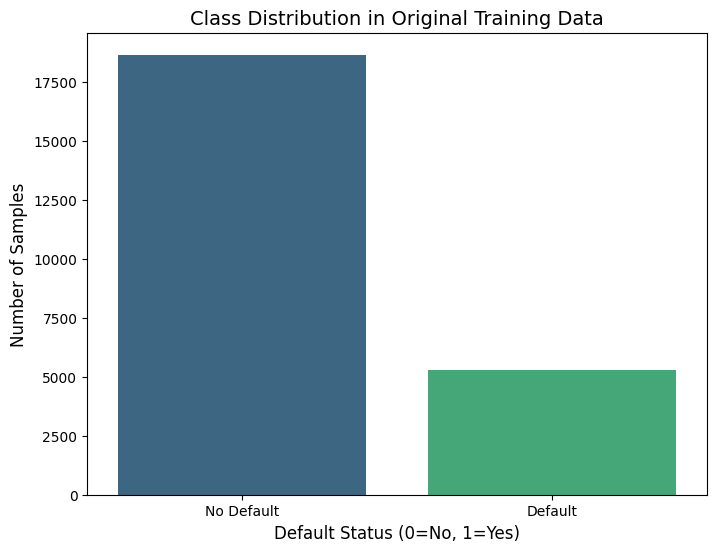

Original training data class distribution:
DEFAULT
0    18668
1     5304
Name: count, dtype: int64


In [39]:
# 1. Show the class imbalance visually (bar chart of class counts in y_train)

plt.figure(figsize=(8, 6))
sns.countplot(x=y_train, palette='viridis')
plt.title('Class Distribution in Original Training Data', fontsize=14)
plt.xlabel('Default Status (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.show()

print("Original training data class distribution:")
print(y_train.value_counts())

Class distribution after SMOTE:
DEFAULT
0    18668
1    18668
Name: count, dtype: int64


/tmp/ipykernel_884/3408560289.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, palette='viridis')


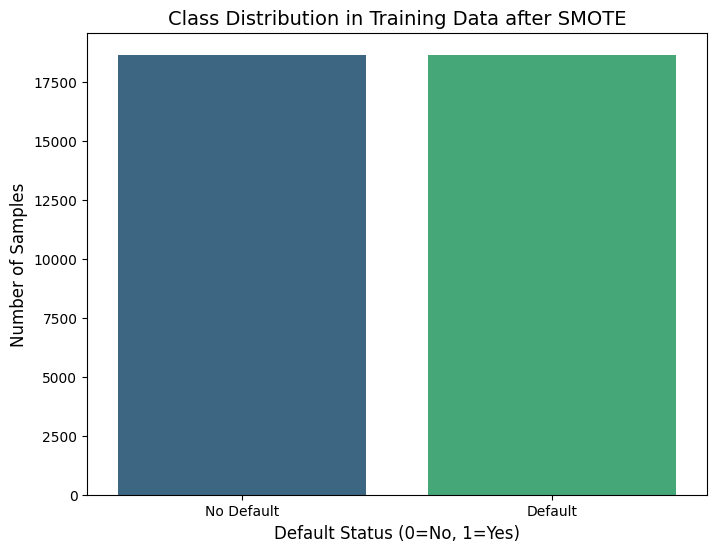

In [40]:
# 2. Apply SMOTE (Synthetic Minority Oversampling Technique)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(y_train_smote.value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_smote, palette='viridis')
plt.title('Class Distribution in Training Data after SMOTE', fontsize=14)
plt.xlabel('Default Status (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.show()

Class distribution after ADASYN:
DEFAULT
1    19135
0    18668
Name: count, dtype: int64


/tmp/ipykernel_884/2898802593.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_adasyn, palette='viridis')


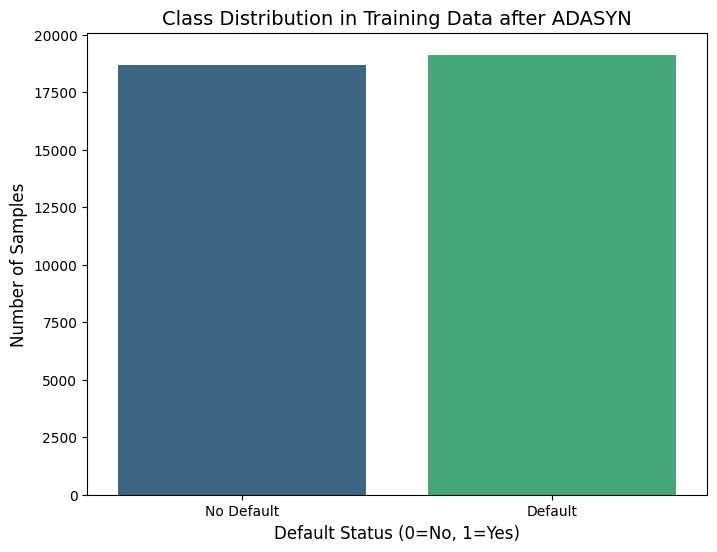

In [41]:
# 3. Apply ADASYN (Adaptive Synthetic Sampling)

from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("Class distribution after ADASYN:")
print(y_train_adasyn.value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_adasyn, palette='viridis')
plt.title('Class Distribution in Training Data after ADASYN', fontsize=14)
plt.xlabel('Default Status (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.show()

/tmp/ipykernel_884/209659604.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, ax=axes[0], palette='viridis')
/tmp/ipykernel_884/209659604.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_adasyn, ax=axes[1], palette='plasma')


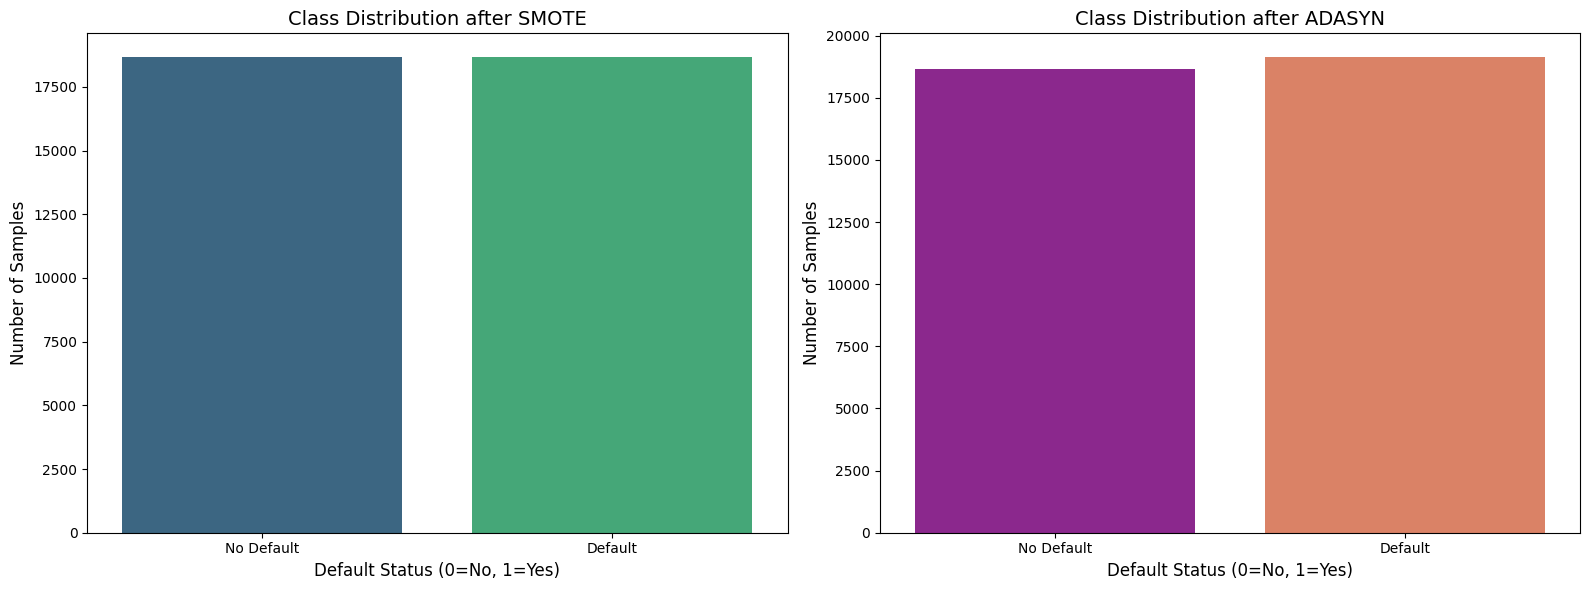

In [42]:
# 4. Compare SMOTE vs ADASYN in a side-by-side countplot

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x=y_train_smote, ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution after SMOTE', fontsize=14)
axes[0].set_xlabel('Default Status (0=No, 1=Yes)', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_xticks(ticks=[0, 1], labels=['No Default', 'Default'])

sns.countplot(x=y_train_adasyn, ax=axes[1], palette='plasma')
axes[1].set_title('Class Distribution after ADASYN', fontsize=14)
axes[1].set_xlabel('Default Status (0=No, 1=Yes)', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_xticks(ticks=[0, 1], labels=['No Default', 'Default'])

plt.tight_layout()
plt.show()

Addressing class imbalance is critical in credit risk prediction to prevent models from being biased towards the majority class (non-defaulters), which can lead to a high number of missed defaulters (false negatives).

### What is SMOTE? (Synthetic Minority Oversampling Technique)

Imagine you're a bank manager trying to identify customers who might default next month. You have a huge database of customers, but only a small fraction have defaulted in the past. If you train an AI model on this data, it's like teaching a new employee by only showing them examples of non-defaulters. They'll get very good at recognizing non-defaulters but will likely miss many potential defaulters simply because they haven't seen enough examples.

SMOTE is like asking that employee to *imagine* new, plausible examples of defaulters based on the characteristics of the defaulters they *have* seen. It creates synthetic (artificial) samples for the minority class (defaulters) by taking a minority class sample, finding its nearest neighbors, and creating a new sample somewhere along the line connecting the original sample and its neighbors. This balances the dataset, giving the model more 'examples' to learn from the rare but critical defaulter class.

### Why apply it only to TRAINING data?

We apply SMOTE (or ADASYN) **only to the training data** (`X_train_smote`, `y_train_smote`) and never to the test data. This is crucial to prevent **data leakage**. If synthetic samples were generated in the test set, our model would be evaluated on data it has essentially 'seen' during training, leading to an overly optimistic and unrealistic assessment of its performance. The test set must remain untouched and truly unseen to provide an unbiased evaluation of how well our model will generalize to new, real-world data.

### Business Risk of Not Handling Imbalance

In credit default prediction, the business objective is often to **minimize false negatives** – that is, incorrectly predicting a defaulter as a non-defaulter. Each false negative represents a potential financial loss for the bank or NBFC. If we don't handle class imbalance, a model might achieve high overall accuracy by simply predicting 'non-defaulter' for almost everyone, as non-defaulters are the majority. However, its ability to identify the risky minority (defaulters) would be very poor, leading to significant financial exposure and ineffective risk management.

### SMOTE vs. ADASYN and the choice for ANN

Both SMOTE and ADASYN are oversampling techniques. ADASYN is an improvement over SMOTE because it focuses on generating synthetic samples for minority class examples that are harder to learn (i.e., those that are closer to the decision boundary). This can sometimes lead to better performance by improving the model's ability to differentiate between the classes, especially for complex non-linear models like ANNs.

For training our Artificial Neural Network, we will proceed with the data rebalanced using **SMOTE (`X_train_smote` and `y_train_smote`)**.

While ADASYN can sometimes offer slight improvements, SMOTE is generally robust and less prone to generating noise if the minority class is very sparse. Given the nature of this dataset and the potential for increased complexity with ADASYN, SMOTE provides a good balance between effectiveness and stability for our ANN. This ensures that our model has sufficient, representative examples of both defaulters and non-defaulters to learn from, without introducing excessive synthetic noise.

## Summary of Preprocessing Steps

| Step                       | Description                                                                                                                                                                                                                           |
| :------------------------- | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **1. Dataset Reloading**   | The original dataset was reloaded from its source to ensure a fresh starting point for all subsequent preprocessing steps.                                                                                                                |
| **2. Target Renaming**     | The target column `'default payment next month'` was renamed to `'DEFAULT'` for clarity and ease of use.                                                                                                                              |
| **3. ID Column Dropped**   | The `'ID'` column was removed as it's a unique identifier and holds no predictive information.                                                                                                                                        |
| **4. Missing Value Check** | Inspected the dataset for any missing values (`.isnull().sum()`) and confirmed no missing data.                                                                                                                                          |
| **5. Duplicate Rows Dropped** | Identified and removed 35 duplicate rows to ensure data integrity and prevent model bias.                                                                                                                                              |
| **6. Invalid Category Handling** | Corrected invalid entries in categorical columns:  `EDUCATION` (0, 5, 6 mapped to 4) and `MARRIAGE` (0 mapped to 3). Noted that `PAY_X` values (-1, -2) are valid and kept as is.                                                                                                                            |
| **7. One-Hot Encoding**    | `SEX`, `EDUCATION`, and `MARRIAGE` columns were converted into numerical binary features using `pd.get_dummies(drop_first=True)` to enable their use in the ANN.                                                                         |
| **8. Feature/Target Split** | The dataset was divided into features (`X`) and the target variable (`y`) for supervised learning.                                                                                                                                    |
| **9. Train/Test Split**    | Data was split into 80% training and 20% testing sets using `train_test_split` with `stratify=y` to maintain the original class distribution in both sets, crucial for imbalanced data.                                                |
| **10. SMOTE Resampling**   | Synthetic Minority Over-sampling Technique (SMOTE) was applied to the *training data only* (`X_train_res`, `y_train_res`) to balance the class distribution, helping the ANN learn from the minority class more effectively.                 |
| **11. Outlier Treatment**  | Outliers in key numerical features (`LIMIT_BAL`, `AGE`, `BILL_AMT`s, `PAY_AMT`s) were capped at the 1st and 99th percentiles (Winsorization) based on the training data. This makes the model more robust to extreme values and prevents issues like exploding gradients. |
| **12. Feature Scaling**    | All continuous and ordinal numerical features (including `PAY_X` columns this time) were standardized using `StandardScaler`, fitting on the training data and transforming both training and test sets. This ensures efficient and stable ANN training by normalizing feature scales. |



Evaluating the model on the test set...

Test Loss: 0.5319
Test Accuracy: 0.7514
Test Precision: 0.4518
Test Recall: 0.5799
Test AUC: 0.7563
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      4667
           1       0.45      0.58      0.51      1326

    accuracy                           0.75      5993
   macro avg       0.66      0.69      0.67      5993
weighted avg       0.78      0.75      0.76      5993



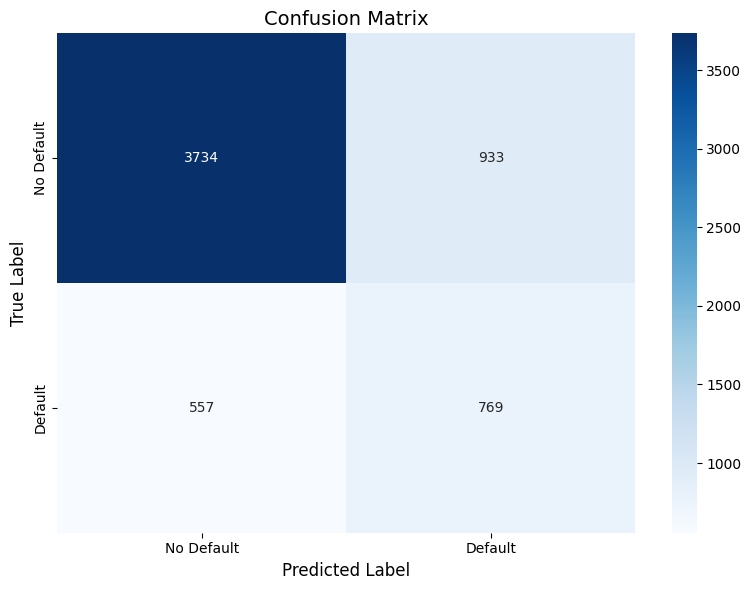

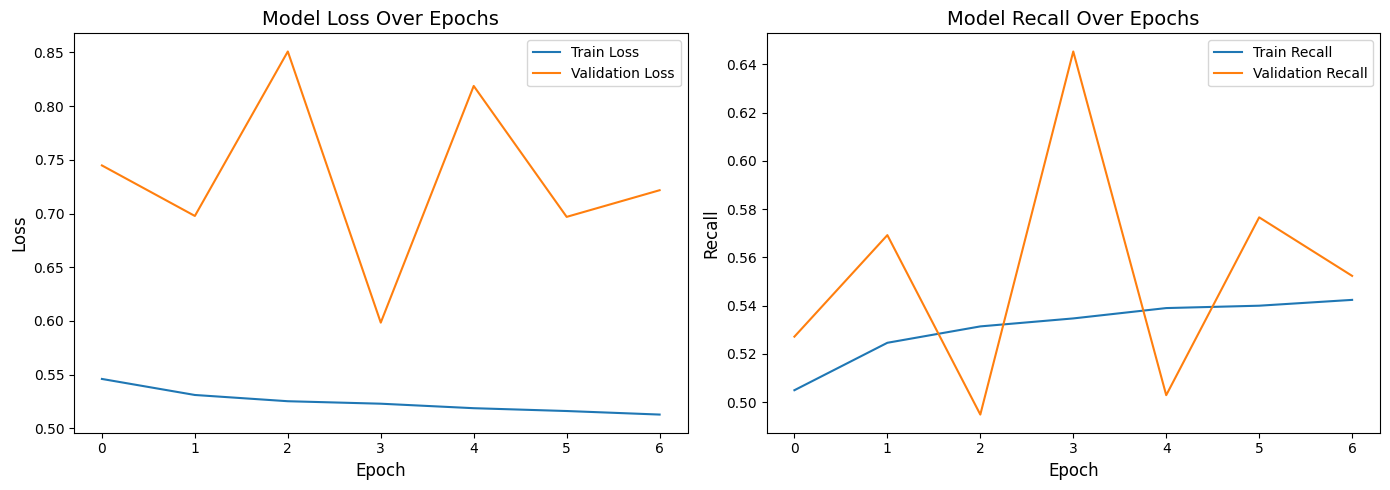

In [31]:
# 2. Evaluate the Model on the Test Set

print("\nEvaluating the model on the test set...")
loss, accuracy, precision, recall, auc = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test AUC: {auc:.4f}")

# Generate predictions
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Plot training history (Loss and Recall)
plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()

# Plot Recall
plt.subplot(1, 2, 2)
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')
plt.title('Model Recall Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

After training, we evaluate our model on the unseen test set to assess its real-world performance. We focus on key metrics such as **Recall** (to measure how many actual defaulters our model correctly identified) and **Precision** (to see how many of our predicted defaulters were truly defaulters). The **Confusion Matrix** provides a detailed breakdown of correct and incorrect predictions, highlighting false negatives and false positives. The `Classification Report` offers a comprehensive summary of these metrics. Finally, plotting the training history helps us understand the learning process and detect potential overfitting by observing the trends in loss and recall on both training and validation datasets over epochs.

This step is about cleaning and organizing our dataset. We've taken two important actions:

1.  **Renamed a column:** The original column name for our target variable ('default payment next month') was a bit long. We've shortened it to 'default_payment_next_month' for easier use in our code. This is like giving a clear, concise label to an important category in a business report.
2.  **Removed the 'ID' column:** Each row in our dataset has a unique 'ID' number. While useful for identification, this number doesn't tell us anything about whether a customer will default or not. Including it in our model would be like using an invoice number to predict sales—it's irrelevant. So, we've removed it to simplify our data and focus on meaningful information.

The output shows the first few rows of our modified dataset and a list of the new column names, confirming these changes were successful.